In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

file_path = "/content/drive/MyDrive/OIL/Dataset/TrainDataV2.xlsx"
df = pd.read_excel(file_path)
df.head(5)


,Ngày,MG95,DO 0.001%,DO 0.05%,BRT DTD,BRT KH,WTI,NgayTrongTuan,ThangTrongNam,QuyTrongNam,Nam,NgayLe,SuKienDacBiet,USD_Index,MG92,GPRD
0,2008-05-02,115.10,NaN,141.14,111.895,113.73,116.330,5,5,2,2008,0,0,87.2311,114.37,57.530880
1,2008-05-05,120.11,NaN,144.12,116.500,117.59,119.980,1,5,2,2008,0,0,87.0636,119.39,42.076496
2,2008-05-06,123.69,NaN,147.23,119.625,120.46,121.855,2,5,2,2008,0,0,86.8470,123.02,76.230637
3,2008-05-07,126.02,NaN,148.00,119.525,120.58,123.545,3,5,2,2008,0,0,87.3421,125.40,89.171814
4,2008-05-08,126.92,NaN,151.19,119.620,121.28,123.710,4,5,2,2008,0,0,87.4575,126.30,55.673409


#Trực quan hóa dữ liệu

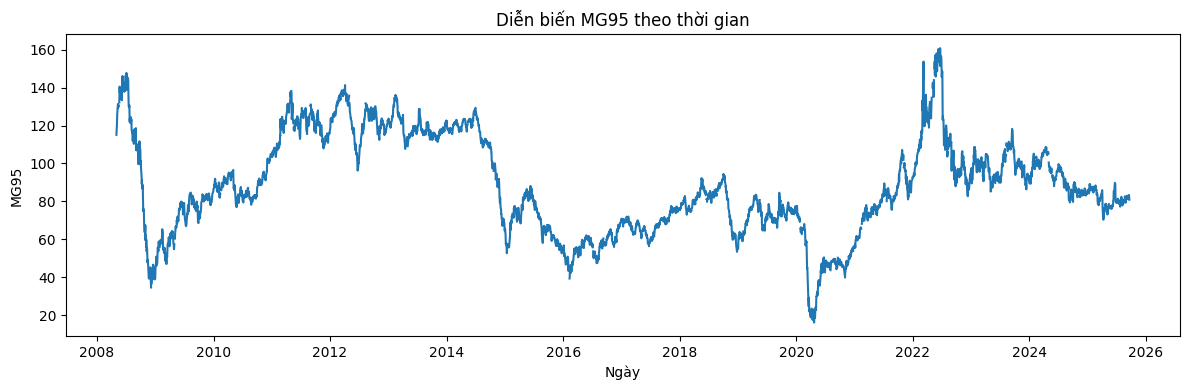

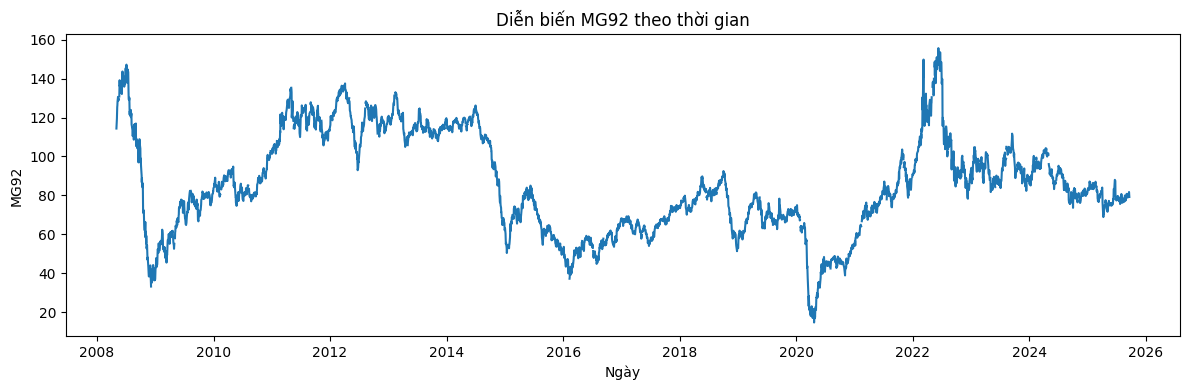

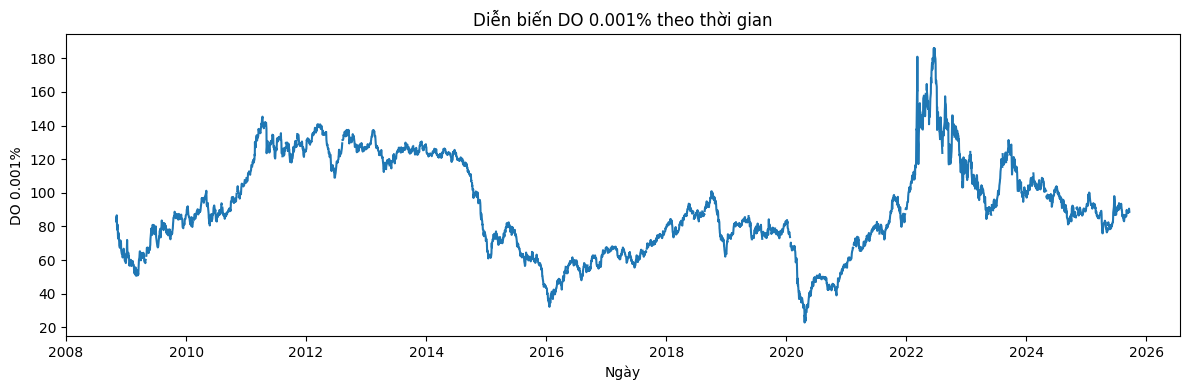

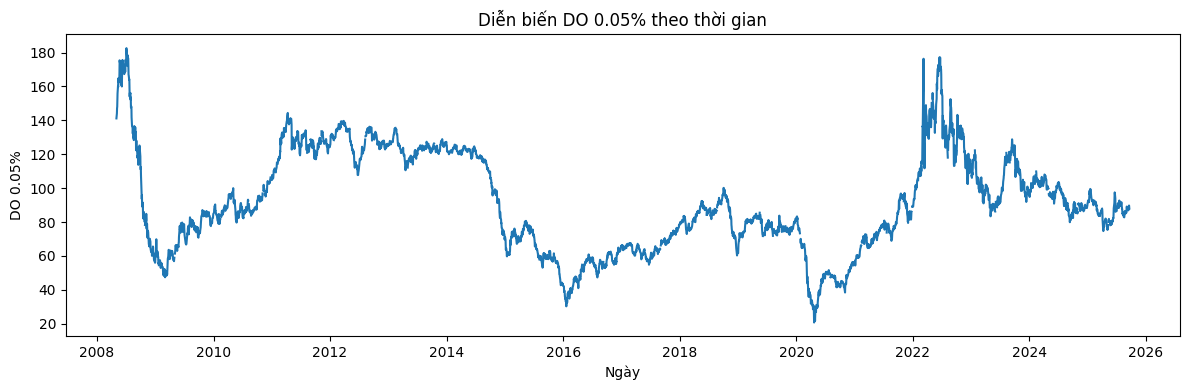

In [ ]:
df["Ngày"] = pd.to_datetime(df["Ngày"])
targets = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]

for col in targets:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(df["Ngày"], df[col])
        plt.xlabel("Ngày")
        plt.ylabel(col)
        plt.title(f"Diễn biến {col} theo thời gian")
        plt.tight_layout()
        plt.show()



                   MG95      MG92  DO 0.001%  DO 0.05%
MG95           1.000000  0.998948   0.965208  0.965123
DO 0.001%      0.965208  0.963892   1.000000  0.998998
DO 0.05%       0.965123  0.965692   0.998998  1.000000
BRT DTD        0.978636  0.982448   0.969368  0.974890
BRT KH         0.975373  0.980011   0.967144  0.974254
WTI            0.952014  0.956538   0.951259  0.958493
NgayTrongTuan  0.006345  0.006257   0.008886  0.008549
ThangTrongNam -0.040699 -0.044303   0.006184  0.007617
QuyTrongNam   -0.041143 -0.045091   0.008325  0.008092
Nam           -0.188242 -0.206131  -0.095718 -0.179984
NgayLe        -0.003772 -0.003836  -0.004100 -0.004415
SuKienDacBiet  0.000496  0.000527   0.007348  0.003682
USD_Index     -0.468415 -0.487603  -0.366639 -0.429337
MG92           0.998948  1.000000   0.963892  0.965692
GPRD           0.095264  0.087690   0.135480  0.103062


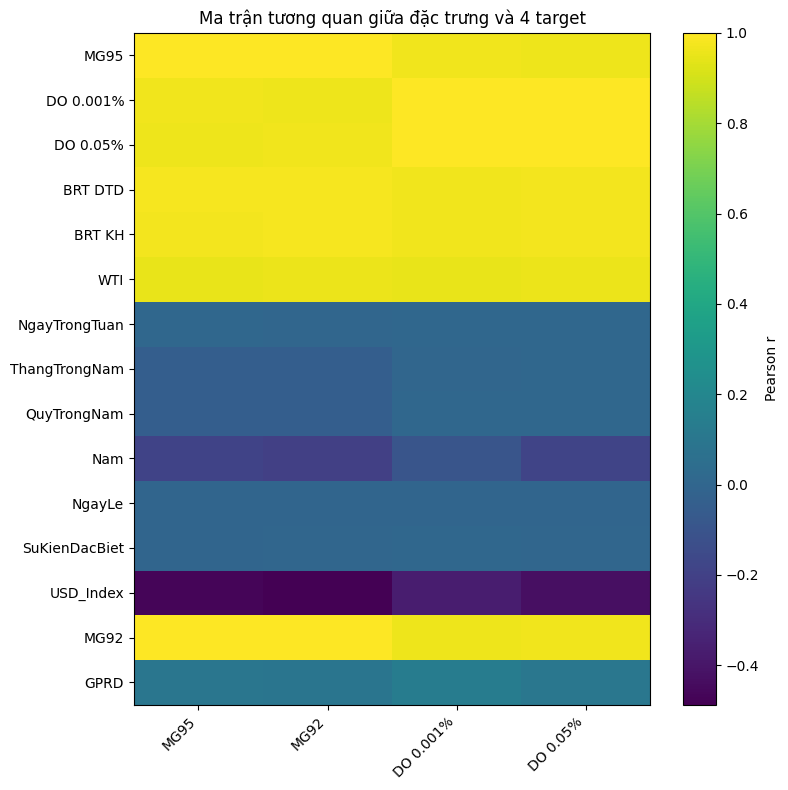

In [ ]:
numeric_df = df.select_dtypes(include=["number"]).copy()
valid_targets = [c for c in targets if c in numeric_df.columns]

# Ma trận tương quan
corr_matrix = numeric_df.corr(method="pearson")[valid_targets]

print(corr_matrix)

# corr_matrix.to_excel("corr_features_vs_targets.xlsx")

# heatmap
plt.figure(figsize=(8, 8))
im = plt.imshow(corr_matrix.values, aspect="auto")
plt.xticks(range(len(valid_targets)), valid_targets, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar(im, label="Pearson r")
plt.title("Ma trận tương quan giữa đặc trưng và 4 target")
plt.tight_layout()
plt.show()



Tương quan của USD_Index với tất cả đặc trưng số:
USD_Index        1.000000
Nam              0.908031
GPRD             0.316943
NgayLe           0.004503
NgayTrongTuan    0.002793
SuKienDacBiet    0.002346
ThangTrongNam   -0.012430
QuyTrongNam     -0.013561
DO 0.001%       -0.366639
DO 0.05%        -0.429337
MG95            -0.468415
MG92            -0.487603
WTI             -0.507749
BRT DTD         -0.516851
BRT KH          -0.540419
Name: USD_Index, dtype: float64

Tương quan của MG95 với tất cả đặc trưng số:
MG95             1.000000
MG92             0.998948
BRT DTD          0.978636
BRT KH           0.975373
DO 0.001%        0.965208
DO 0.05%         0.965123
WTI              0.952014
GPRD             0.095264
NgayTrongTuan    0.006345
SuKienDacBiet    0.000496
NgayLe          -0.003772
ThangTrongNam   -0.040699
QuyTrongNam     -0.041143
Nam             -0.188242
USD_Index       -0.468415
Name: MG95, dtype: float64


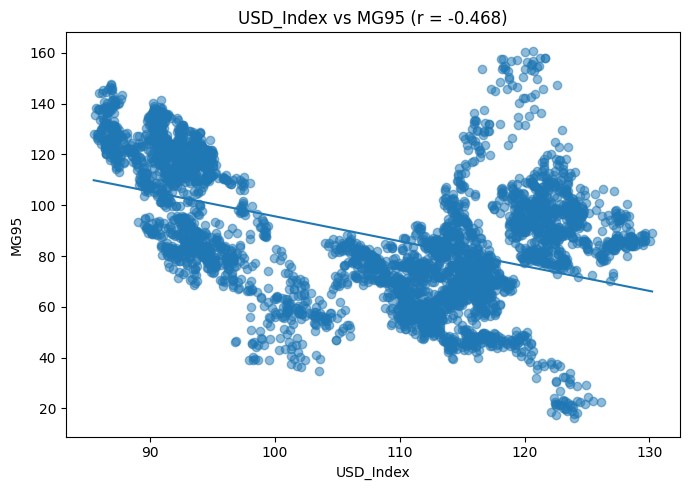

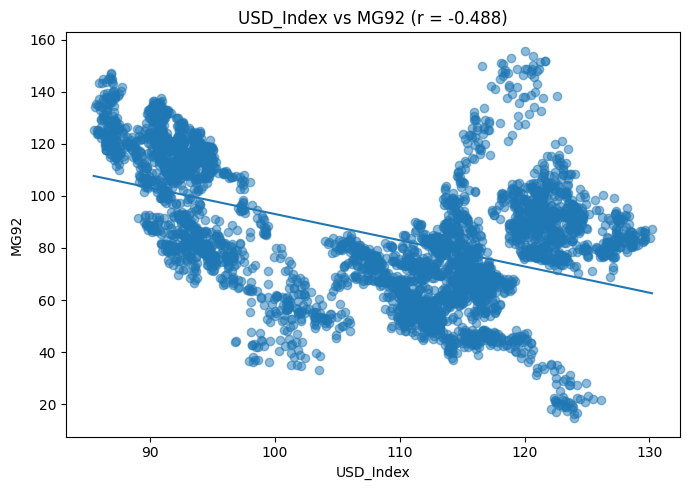

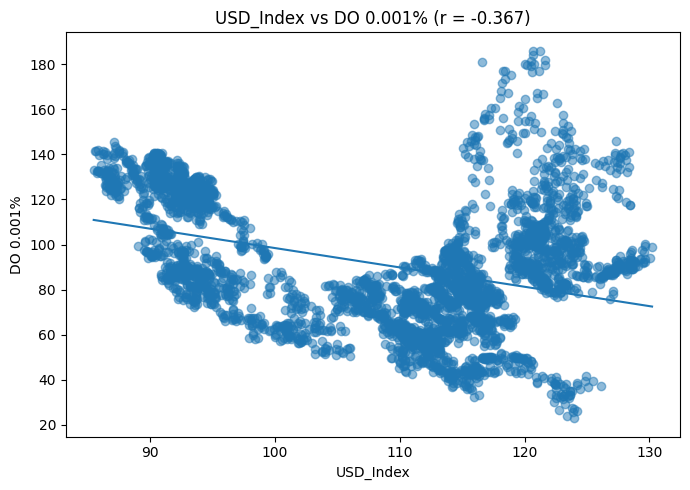

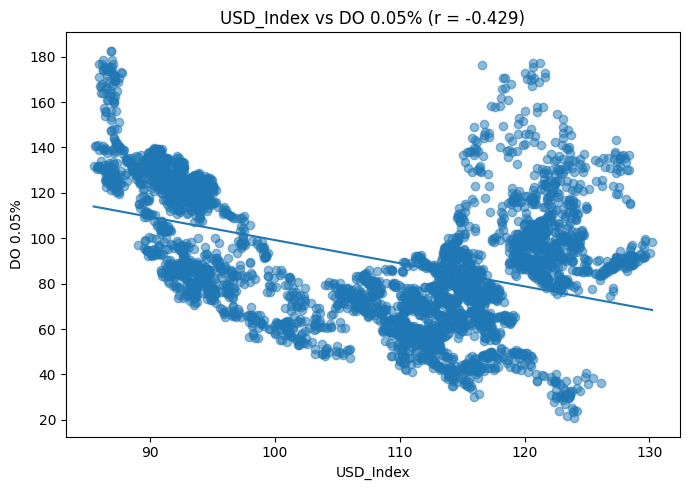

In [ ]:
numeric_df = df.select_dtypes(include=["number"]).copy()

corr_usd_all = numeric_df.corr()["USD_Index"].sort_values(ascending=False)
print("\nTương quan của USD_Index với tất cả đặc trưng số:")
print(corr_usd_all)

corr_usd_all.to_frame("corr_with_USD_Index").to_excel("corr_with_USD_Index.xlsx")

corr_mg95_all = numeric_df.corr()["MG95"].sort_values(ascending=False)
print("\nTương quan của MG95 với tất cả đặc trưng số:")
print(corr_mg95_all)

corr_mg95_all.to_frame("corr_with_MG95").to_excel("corr_with_MG95.xlsx")
targets = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]

for col in targets:
    if col in df.columns:
        x = df["USD_Index"]
        y = df[col]
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]
        r = x.corr(y)

        plt.figure(figsize=(7, 5))
        plt.scatter(x, y, alpha=0.5)
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_line, m * x_line + b)

        plt.xlabel("USD_Index")
        plt.ylabel(col)
        plt.title(f"USD_Index vs {col} (r = {r:.3f})")
        plt.tight_layout()
        plt.show()

### Mối quan hệ giữa USD_Index và giá xăng/dầu

- Trục X là **USD_Index**, trục Y lần lượt là **MG95, MG92, DO 0.001%, DO 0.05%**.  
- Hệ số tương quan Pearson r lần lượt khoảng:  
  - USD_Index – MG95: **r ≈ -0.47**  
  - USD_Index – MG92: **r ≈ -0.49**  
  - USD_Index – DO 0.001%: **r ≈ -0.37**  
  - USD_Index – DO 0.05%: **r ≈ -0.43**  
- Tất cả đều **âm** và có độ lớn vừa → khi **USD_Index tăng**, giá xăng/dầu **có xu hướng giảm** (hoặc tăng chậm lại).  
- Các điểm dữ liệu tạo thành nhiều “cụm” theo từng giai đoạn thị trường, nên quan hệ không hoàn toàn tuyến tính, nhưng xu hướng chung vẫn là **ngược chiều**.  
- Vì vậy, **USD_Index là một đặc trưng quan trọng** cần đưa vào mô hình dự báo, với tác động ngược chiều lên 4 sản phẩm xăng/dầu.


Features sẽ vẽ: ['BRT DTD', 'BRT KH', 'WTI', 'NgayTrongTuan', 'ThangTrongNam', 'QuyTrongNam', 'Nam', 'NgayLe', 'SuKienDacBiet', 'USD_Index', 'GPRD']


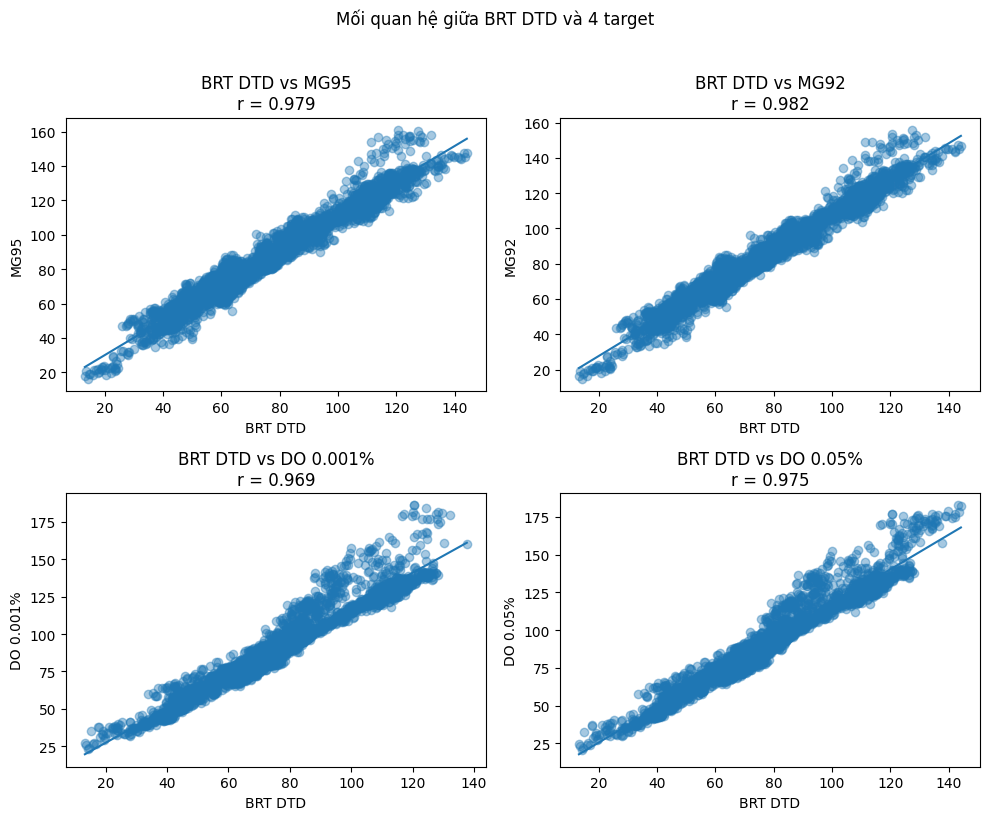

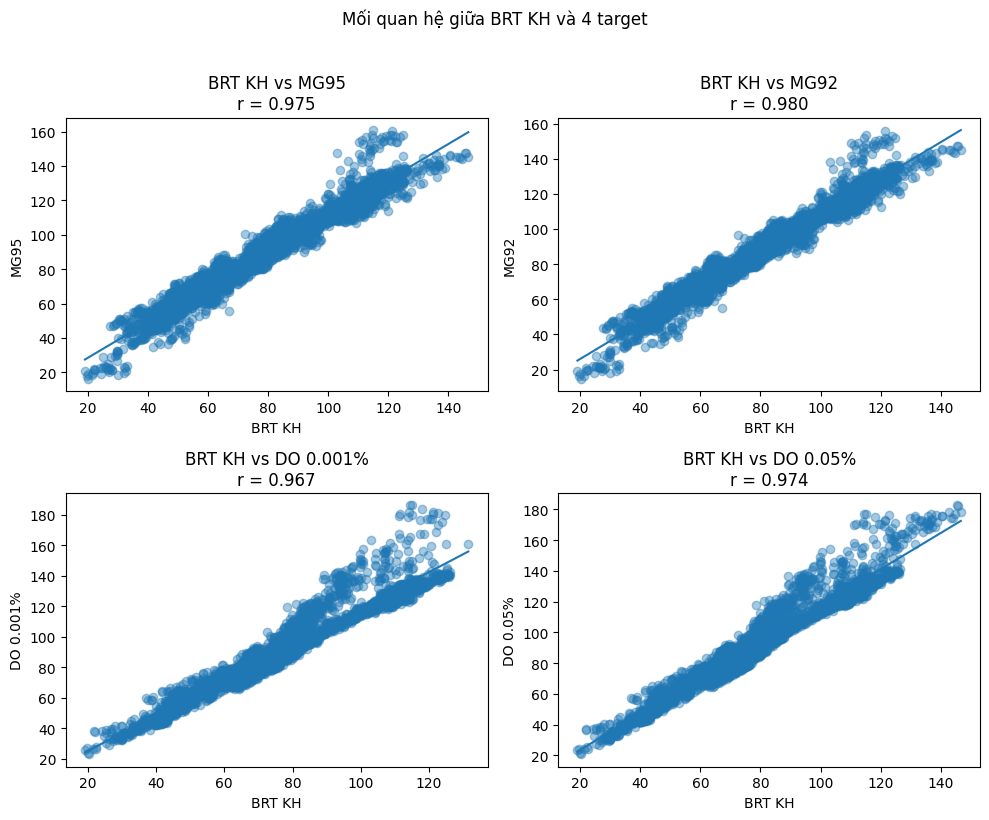

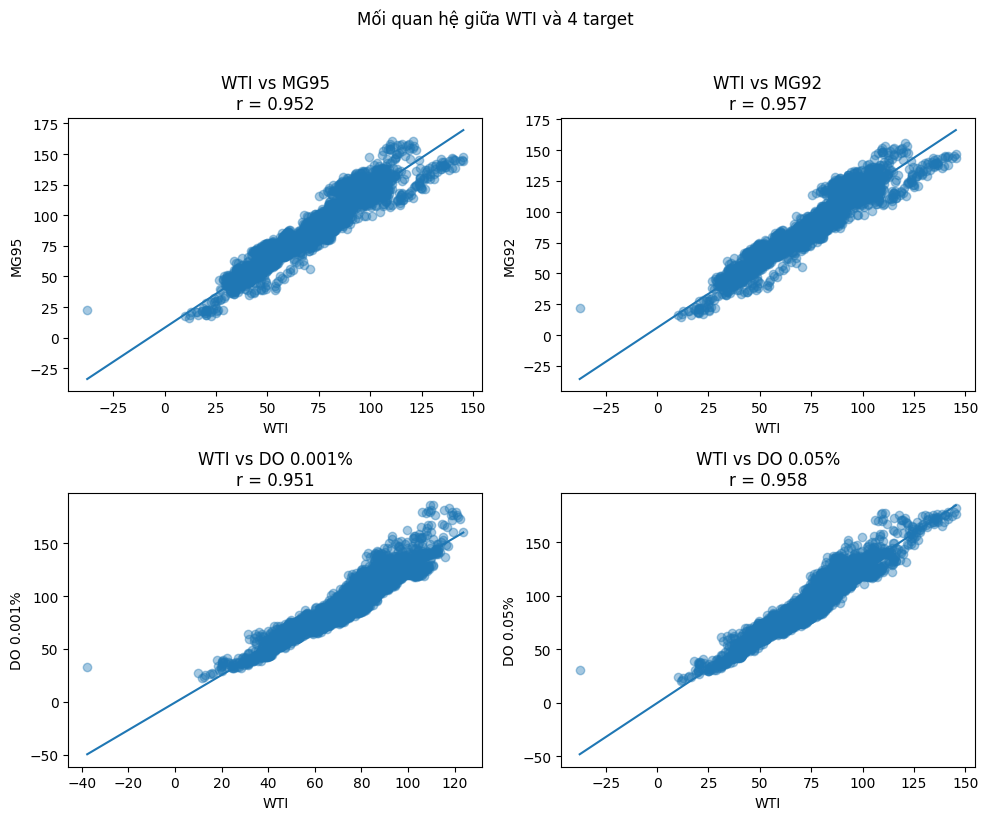

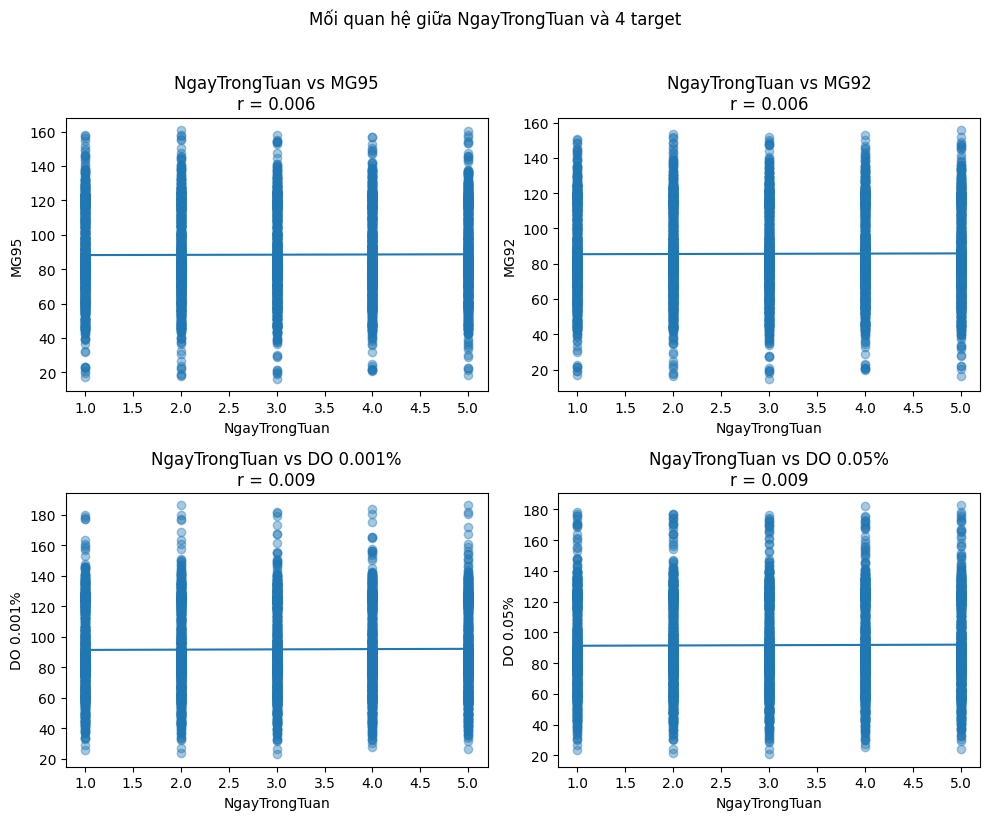

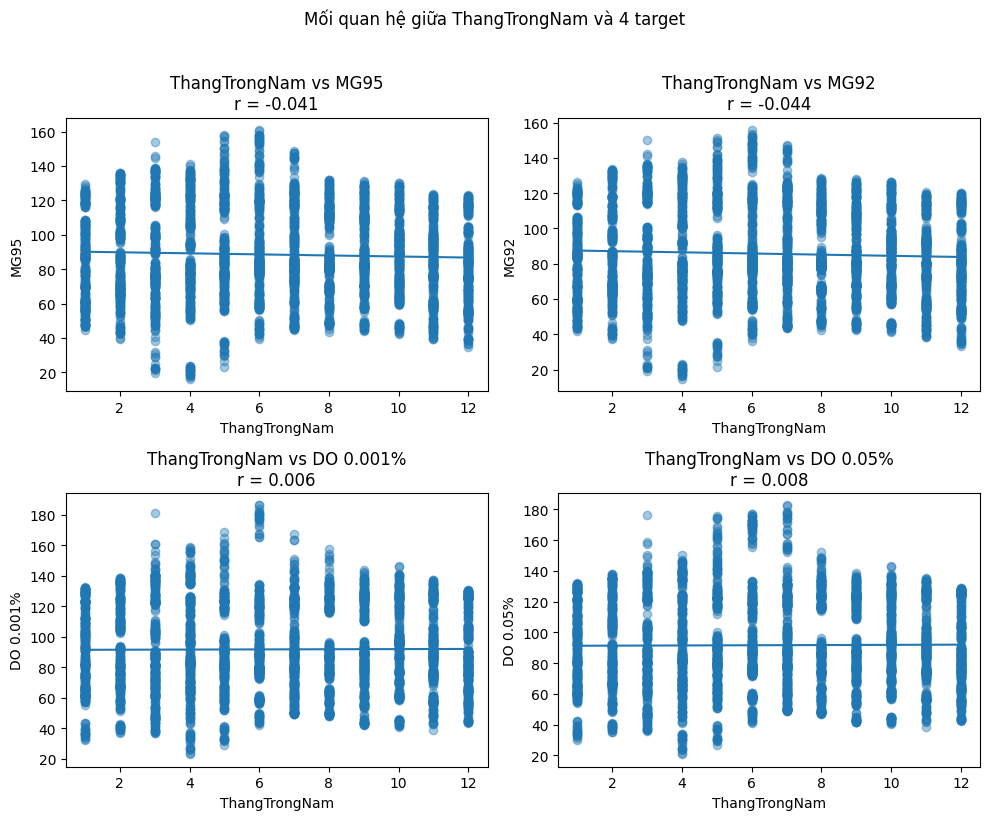

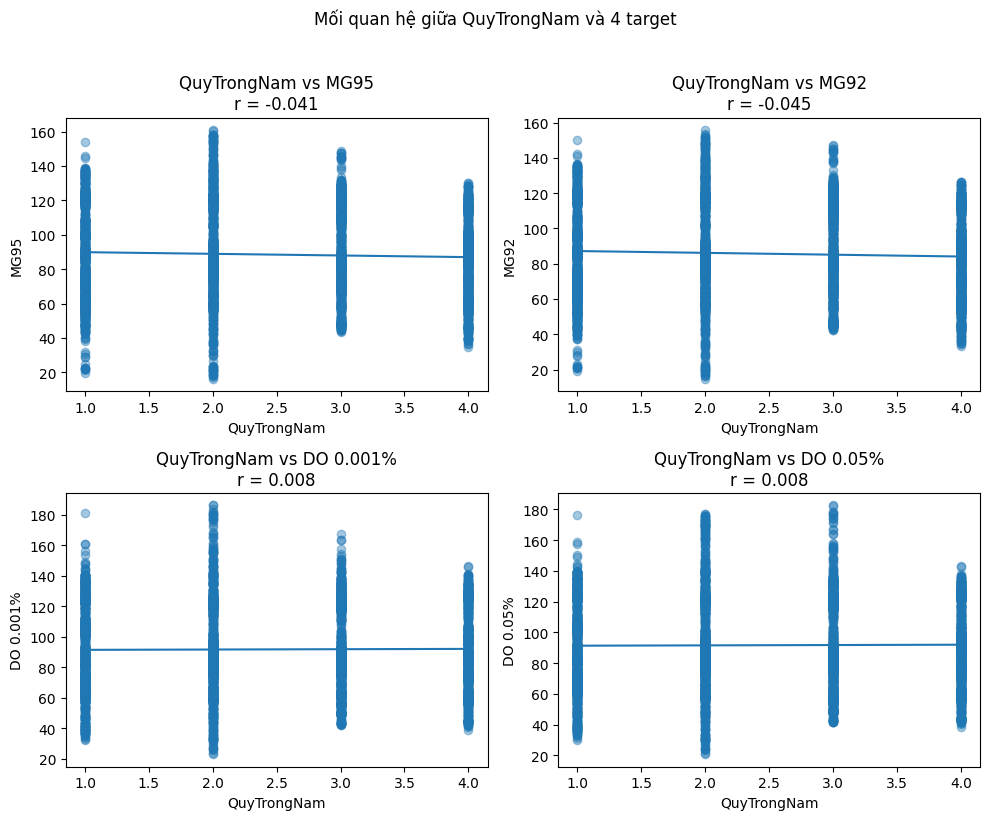

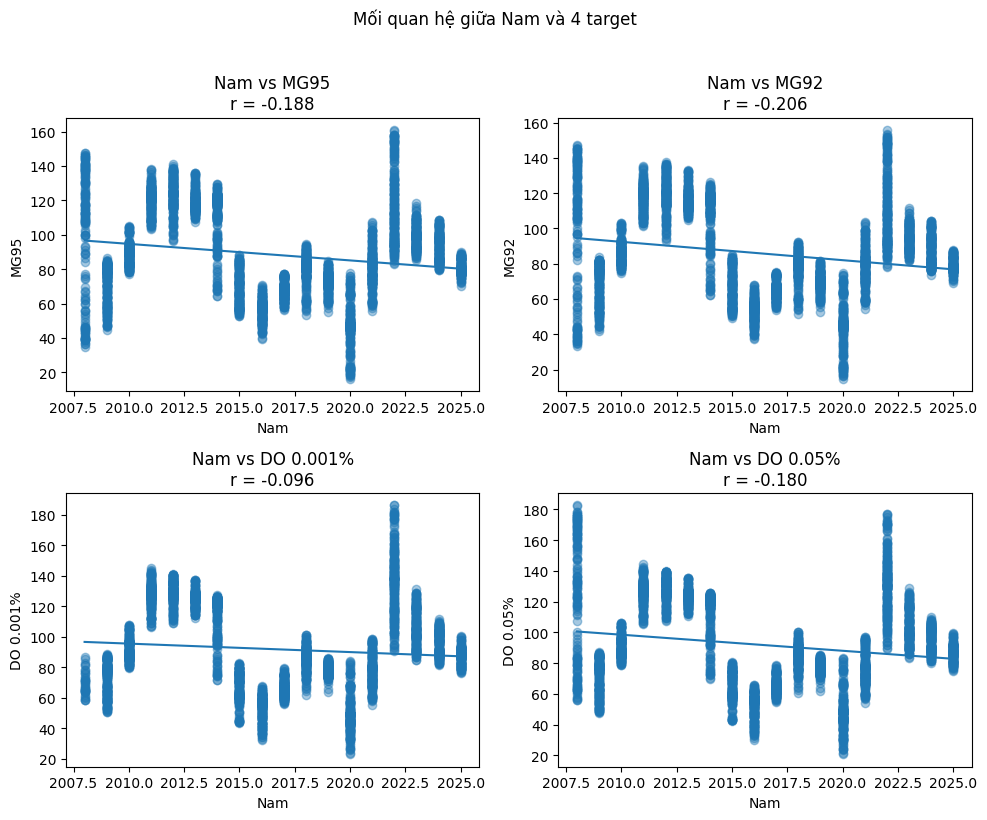

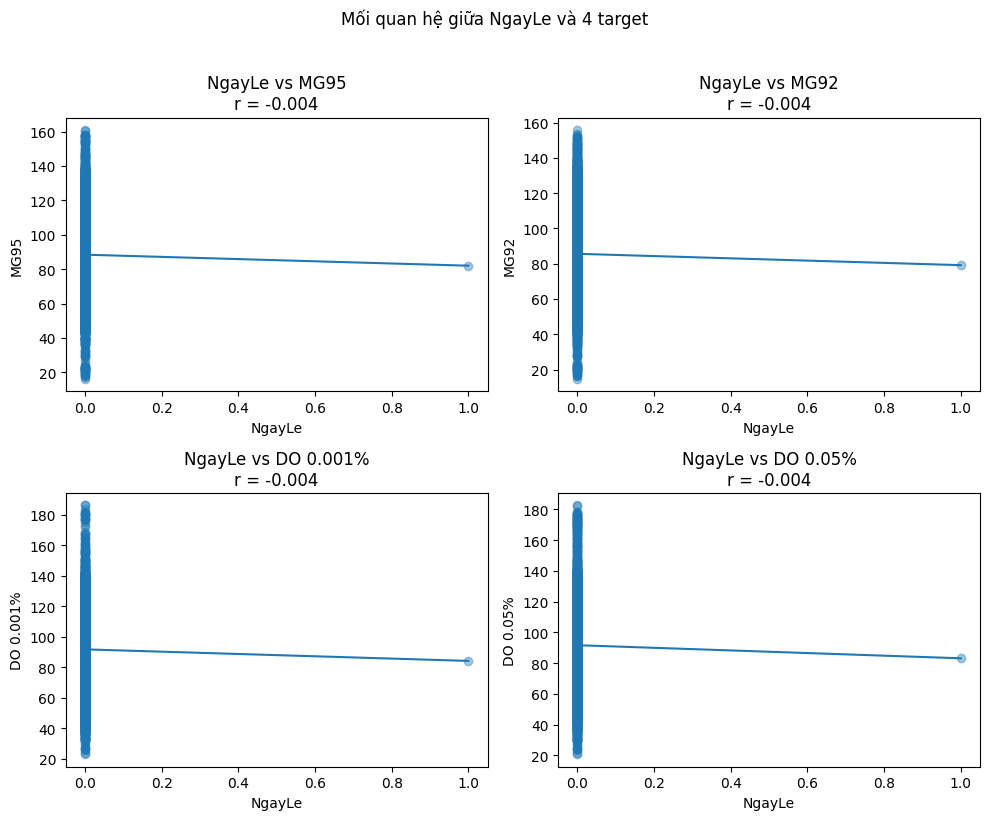

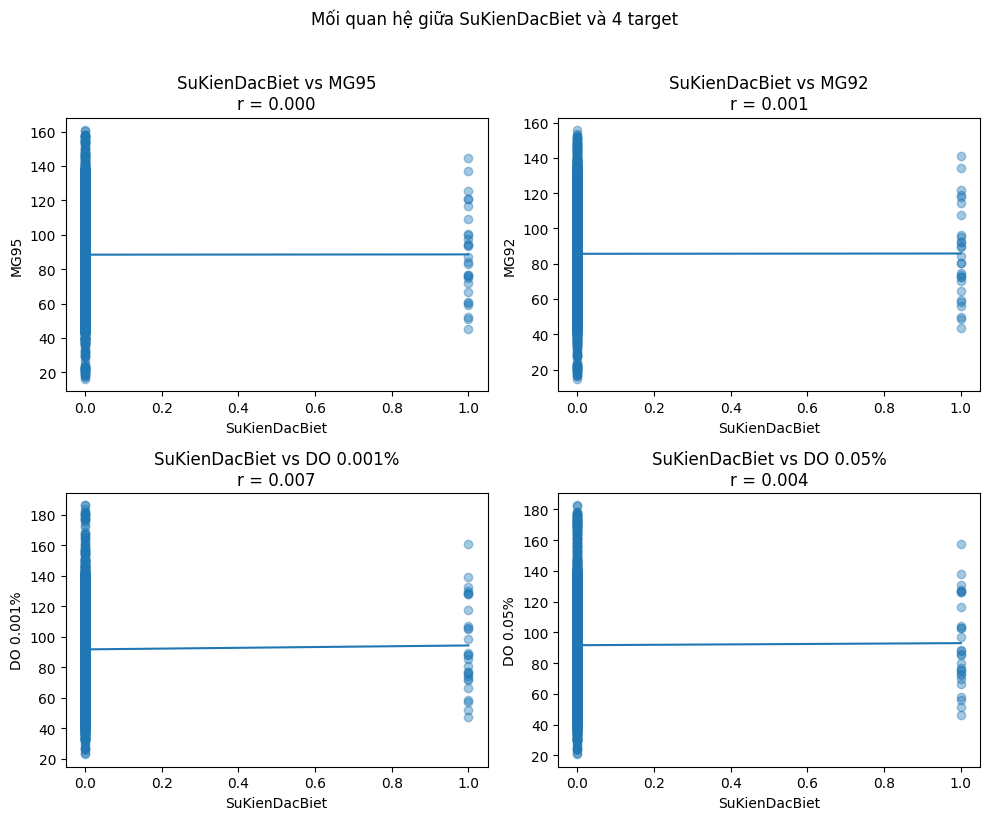

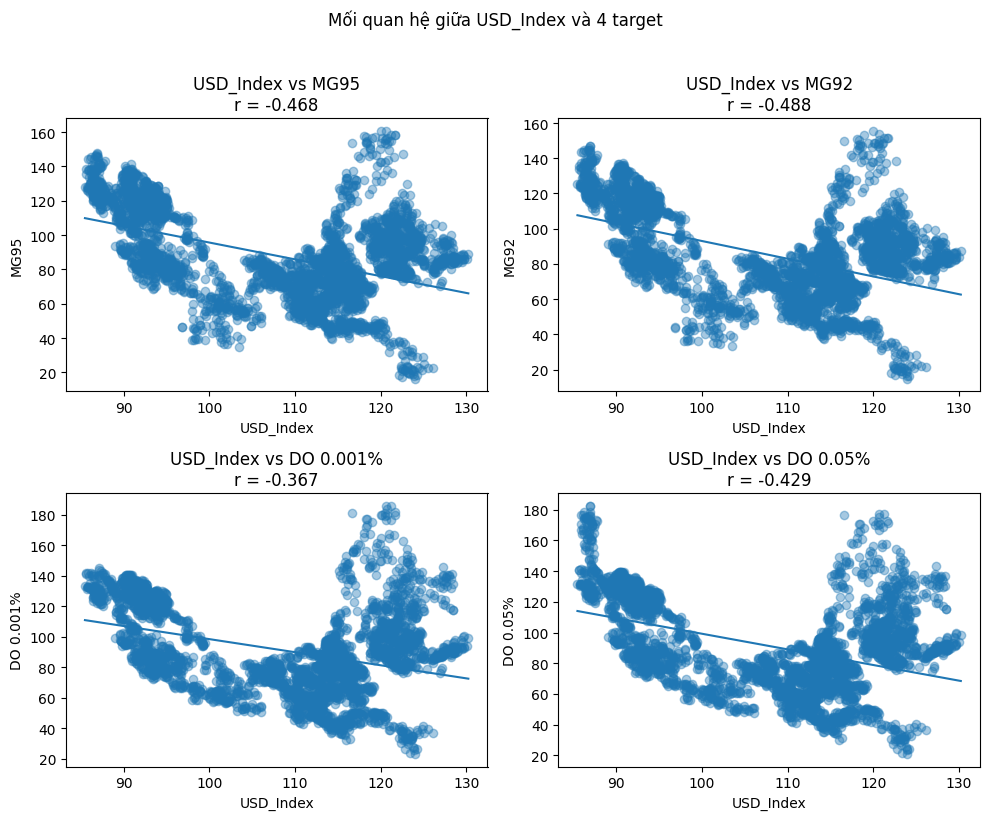

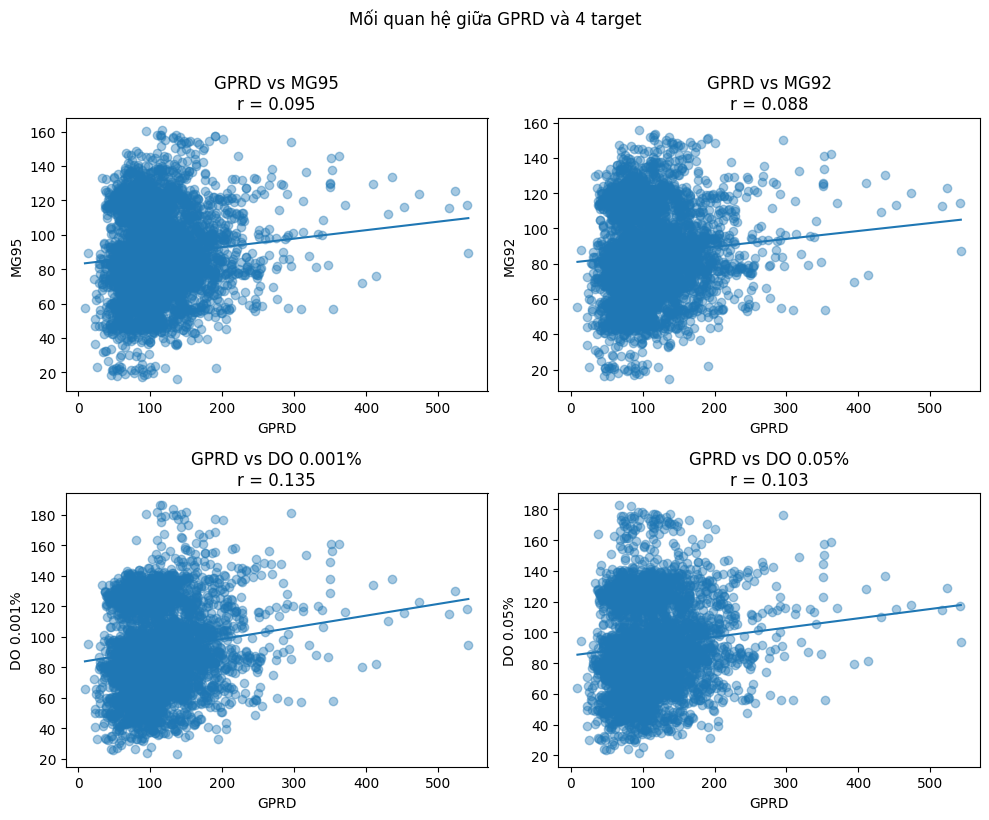

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

features = [c for c in numeric_df.columns if c not in targets]

print("Features sẽ vẽ:", features)

for feat in features:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()

    for i, target in enumerate(targets):
        ax = axes[i]

        x = df[feat]
        y = df[target]

        # Bỏ NaN
        mask = x.notna() & y.notna()
        x_valid = x[mask]
        y_valid = y[mask]


        if len(x_valid) < 2:
            ax.set_visible(False)
            continue

        # Tính tương quan Pearson
        r = x_valid.corr(y_valid)

        # Scatter
        ax.scatter(x_valid, y_valid, alpha=0.4)

        # Đường hồi quy tuyến tính
        m, b = np.polyfit(x_valid, y_valid, 1)
        x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
        ax.plot(x_line, m * x_line + b)

        ax.set_xlabel(feat)
        ax.set_ylabel(target)
        ax.set_title(f"{feat} vs {target}\nr = {r:.3f}")

    plt.suptitle(f"Mối quan hệ giữa {feat} và 4 target", y=1.02)
    plt.tight_layout()
    plt.show()

### Biểu đồ mối quan hệ giữa các đặc trưng và 4 biến mục tiêu

- Với mỗi đặc trưng (BRT DTD, BRT KH, WTI, USD_Index, GPRD, các biến thời gian…), vẽ 4 đồ thị **scatter + đường hồi quy tuyến tính** với 4 target: **MG95, MG92, DO 0.001%, DO 0.05%**.
- Mỗi chấm biểu diễn **giá trị đặc trưng và giá xăng/dầu tại một ngày** trong dữ liệu.
- Đường thẳng trên mỗi subplot cho thấy **xu hướng tuyến tính**:
  - Đường có hệ số dốc dương → **tương quan dương**: đặc trưng tăng thì giá xăng/dầu có xu hướng tăng.
  - Đường có hệ số dốc âm → **tương quan âm**: đặc trưng tăng thì giá xăng/dầu có xu hướng giảm.
- Hệ số tương quan Pearson \(r\) được ghi trên mỗi subplot:
  - \(|r|\) càng lớn → mối quan hệ tuyến tính càng mạnh.
  - Ví dụ: **BRT DTD, BRT KH, WTI** có \(r\) dương rất cao với cả 4 target → giá dầu thế giới tăng kéo giá xăng/dầu trong nước tăng mạnh.
  - **USD_Index** có \(r\) âm vừa với 4 target → USD_Index tăng thì giá xăng/dầu có xu hướng giảm (ngược chiều).
- Nhờ các biểu đồ này, ta **kiểm chứng trực quan** ma trận tương quan và lựa chọn được các đặc trưng có ảnh hưởng mạnh đến 4 biến mục tiêu.


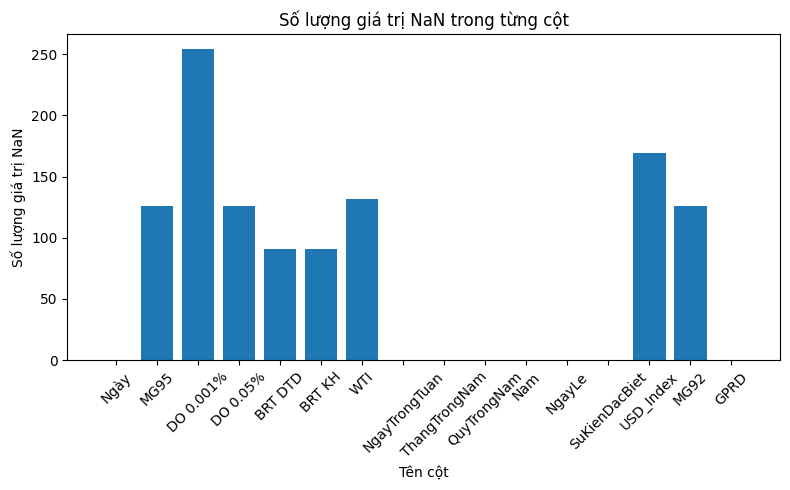

In [ ]:
nan_counts = df.isna().sum()
plt.figure(figsize=(8, 5))
plt.bar(nan_counts.index, nan_counts.values)
plt.title("Số lượng giá trị NaN trong từng cột")
plt.xlabel("Tên cột")
plt.ylabel("Số lượng giá trị NaN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Tiền sử lý dữ liệu

In [ ]:
cont_cols = ["MG92","MG95","DO 0.001%","DO 0.05%","BRT DTD","BRT KH","WTI","USD_Index"]
df = df.sort_index()

- `cont_cols`: Danh sách tên các cột số (biến liên tục) sẽ được áp dụng cùng quy trình tiền xử lý.
- `df = df.sort_index()`: Sắp xếp DataFrame theo index tăng dần để các bước theo thời gian (lag, split theo thời gian, nội suy theo time) chạy đúng.


In [ ]:
def ffill_past_only(s, limit=None, win_med=5):
    x = s.copy()
    x = x.ffill(limit=limit)
    x = x.fillna(x.rolling(win_med, min_periods=1).median())  # past-only
    return x

- `ffill_past_only(s, limit=None, win_med=5)`: Hàm điền khuyết **chỉ dùng dữ liệu quá khứ**.
  - Bước 1: `ffill(limit)` — kéo giá trị trước đó lên để lấp NaN.
  - Bước 2: với phần còn NaN, dùng **rolling median** quá khứ (`window=win_med`, `min_periods=1`) để điền tiếp.
- Dùng khi bạn muốn impute mà **không nhìn tương lai** (an toàn cho chuỗi thời gian).
- Trả về: Series đã được điền NaN theo quy tắc trên.

In [ ]:
def make_lags(frame, cols, lags=(1,2,3)):
    out = {}
    for c in cols:
        if c in frame.columns:
            for L in lags:
                out[f"{c}_lag{L}"] = frame[c].shift(L)
    return pd.DataFrame(out, index=frame.index)

- `make_lags(frame, cols, lags=(1,2,3))`: Tạo **các đặc trưng độ trễ (lag)** cho các cột trong `cols`.
  - Với mỗi cột `c` và mỗi độ trễ `L`, sinh cột `c_lagL = frame[c].shift(L)`.
  - Trả về: DataFrame các cột lag, **cùng index** với `frame`.
  - Lưu ý: các hàng đầu sẽ **NaN** theo giá trị `L` (do thiếu dữ liệu quá khứ).
  - Dùng để mô hình hoá chuỗi thời gian **không rò rỉ tương lai**.


In [ ]:
def _robust_bounds(base: pd.Series, q_lo=0.01, q_hi=0.99, eps=1e-9):
    base = base.dropna()
    if base.size == 0:
        return None, None
    lo, hi = base.quantile(q_lo), base.quantile(q_hi)
    if (hi - lo) <= eps:
        med = base.median()
        mad = np.median(np.abs(base - med)) if base.size > 0 else 0.0
        lo, hi = med - 3*mad, med + 3*mad
        if (hi - lo) <= eps:
            bump = 0.01 * (abs(med) + 1.0)
            lo, hi = med - bump, med + bump
    return lo, hi

- `_robust_bounds(base, q_lo=0.01, q_hi=0.99, eps=1e-9)`: Tính **ngưỡng dưới/trên** để clip dữ liệu một cách **ít nhạy cảm với ngoại lệ**.
  - Lấy quantile `[q_lo, q_hi]`. Nếu khoảng quá hẹp (≈0), chuyển sang **median ± 3*MAD**.
  - Nếu vẫn hẹp, nới thêm một biên nhỏ (±1% theo mức trung vị).
  - Trả về: `(lo, hi)` dùng để `clip`, giúp tránh kẹp dữ liệu về đúng một giá trị.


In [ ]:
def apply_guardrails_on_imputed_smart(df, col, ref_mask=None, clip_q=(0.01,0.99),
                                      max_delta_mult=5.0, skip_mask=None):
    if ref_mask is None:
        ref_mask = df[f"{col}_was_nan"]==0
    base = df.loc[ref_mask, col]
    if base.notna().sum() < 20:
        return

    lo, hi = _robust_bounds(base, q_lo=clip_q[0], q_hi=clip_q[1])
    if lo is not None and hi is not None:
        tgt_mask = ~ref_mask
        if skip_mask is not None:
            tgt_mask = tgt_mask & (~skip_mask)
        df.loc[tgt_mask, col] = df.loc[tgt_mask, col].clip(lo, hi)

    # hạn chế bước nhảy
    d_base = base.diff().dropna()
    if len(d_base) >= 20:
        iqr = d_base.quantile(0.75) - d_base.quantile(0.25)
        max_step = max_delta_mult * (iqr if iqr > 0 else d_base.std(ddof=0))
        vals = df[col].copy()
        for i in range(1, len(vals)):
            if pd.isna(vals.iloc[i]) or pd.isna(vals.iloc[i-1]):
                continue
            step = vals.iloc[i] - vals.iloc[i-1]
            if abs(step) > max_step:
                vals.iloc[i] = vals.iloc[i-1] + np.sign(step)*max_step
        df[col] = vals

- `apply_guardrails_on_imputed_smart(df, col, ref_mask=None, clip_q=(0.01,0.99), max_delta_mult=5.0, skip_mask=None)`  
  Đặt “lan can” cho giá trị đã điền:
  - **Clip mềm** phần đã impute vào khoảng an toàn `(lo, hi)` tính bằng `_robust_bounds` (ít nhạy cảm ngoại lệ).  
    - Bỏ clip ở những vị trí `skip_mask==True` (ví dụ 3 hàng đầu hoặc điểm mới điền).
  - **Giới hạn bước nhảy**: chặn thay đổi giữa 2 thời điểm không vượt quá ngưỡng dựa trên IQR của dữ liệu gốc.
  - `ref_mask`: mask các điểm **gốc** (không phải impute) dùng để ước lượng biên an toàn.


In [ ]:
def _runs_from_mask(mask: pd.Series):
    m = mask.values.astype(bool)
    runs, i, n = [], 0, len(m)
    while i < n:
        if not m[i]:
            i += 1; continue
        j = i
        while j < n and m[j]:
            j += 1
        runs.append((i, j))
        i = j
    return runs

- `_runs_from_mask(mask)`: Tìm các **đoạn liên tiếp** có giá trị `True` trong `mask`.
  - Trả về danh sách các cặp chỉ số `(start, end_exclusive)` cho từng run `True`.
  - Dùng để xác định các khoảng (ví dụ khoảng NaN, khoảng đã impute, …) theo một mặt nạ Boolean.

In [ ]:
def _nan_runs(mask: pd.Series):
    return _runs_from_mask(mask)

- `_nan_runs(mask)`: Tiện ích gọi lại `_runs_from_mask(mask)` để lấy các **đoạn liên tiếp** theo `mask` (thường dùng với `mask = series.isna()` để tìm các run NaN).


In [ ]:
def fill_gaps_with_trend_past_only(s: pd.Series, k=14, min_run=6, add_noise=False, noise_scale=0.3):
    x = s.copy()
    runs = _nan_runs(x.isna())
    diffs = x.dropna().diff().dropna().values
    vol = np.median(np.abs(diffs)) if len(diffs) else 0.0
    for (i, j) in runs:
        if j - i < min_run:
            continue
        left = max(0, i - k)
        past = x.iloc[left:i].dropna()
        if len(past) < 5:
            continue
        t = np.arange(len(past), dtype=float)
        y = past.values.astype(float)
        tt = (t - t[-1]) / max(1.0, np.std(t - t[-1]))
        a, b = np.polyfit(tt, y, 1)
        denom = max(1.0, np.std(t - t[-1]))
        for step, pos in enumerate(range(i, j), start=1):
            yhat = b + a * (step/denom)
            if add_noise and vol > 0:
                yhat += np.random.normal(0, noise_scale*vol)
            x.iloc[pos] = yhat
    return x

- `fill_gaps_with_trend_past_only(s, k=14, min_run=6, add_noise=False, noise_scale=0.3)`  
  Điền các **khoảng NaN dài** bằng **xu hướng từ quá khứ** (không nhìn tương lai):
  - Tìm run NaN có độ dài ≥ `min_run`.
  - Lấy tối đa `k` điểm **trước run** (`past`) để ước lượng **đường thẳng xu hướng** (hệ số `a, b`).
  - Ngoại suy lần lượt vào các vị trí NaN trong run theo đường thẳng này.  
  - Tuỳ chọn thêm nhiễu nhỏ (`add_noise`, `noise_scale`) dựa trên độ biến động lịch sử (`median(|diff|)`).
  - Trả về Series đã được điền các run NaN theo **trend past-only**.


In [ ]:
def deflat_constant_imputed_runs(s: pd.Series,
                                 was_mask: pd.Series,
                                 min_run: int = 6,
                                 flat_tol: float = 1e-9,
                                 past_k: int = 8,
                                 search_back: int = 150,
                                 fallback_slope_mult: float = 0.5):
    x = s.copy()
    idx = s.index
    diffs = x.dropna().diff().dropna().values
    vol = float(np.median(np.abs(diffs))) if len(diffs) else 0.0

    vals = x.values
    n = len(vals)
    i = 0
    while i < n:
        j = i + 1
        while j < n and not pd.isna(vals[j]) and not pd.isna(vals[j-1]) and abs(vals[j] - vals[j-1]) <= flat_tol:
            j += 1
        run_len = j - i
        if run_len >= min_run:
            seg_mask = was_mask.iloc[i:j].fillna(False).values
            if seg_mask.any():
                left = max(0, i - search_back)
                past_idx = idx[left:i]
                true_mask = (~was_mask.loc[past_idx]) & s.loc[past_idx].notna()
                past_vals = s.loc[past_idx][true_mask].tail(past_k)

                if len(past_vals) >= 2:
                    slope = (past_vals.iloc[-1] - past_vals.iloc[0]) / max(1, len(past_vals)-1)
                else:
                    slope = fallback_slope_mult * vol

                start_val = x.iloc[i-1] if i-1 >= 0 and pd.notna(x.iloc[i-1]) else x.iloc[i]
                t = 0
                for pos in range(i, j):
                    if was_mask.iloc[pos] == 1:
                        x.iloc[pos] = start_val + slope * t
                    t += 1
        i = j
    return x

- `deflat_constant_imputed_runs(s, was_mask, min_run=6, flat_tol=1e-9, past_k=8, search_back=150, fallback_slope_mult=0.5)`  
  Phá **đoạn phẳng** dài trong chuỗi **tại các điểm đã điền** (`was_mask==1`):
  - Phát hiện đoạn phẳng (biến động ≤ `flat_tol`) dài ≥ `min_run`.
  - Ước **độ dốc past-only** từ `past_k` điểm thật ngay trước đoạn (nhìn lùi tối đa `search_back` bước).  
    Thiếu dữ liệu thì dùng dốc nhỏ `fallback_slope_mult * median(|diff|)`.
  - Chỉ thay đổi **các vị trí đã impute**, giữ nguyên dữ liệu gốc.
  - Trả về chuỗi đã được “nắn” để **bớt phẳng** nhưng không rò rỉ tương lai.


In [ ]:
def seed_head_with_small_slope(df, col, max_head=3, use_future=True):
    y = df[col].copy()
    head_len = int((y.isna()).cumprod().sum())
    if head_len == 0 or head_len >= len(y):
        return
    if pd.isna(y.iloc[head_len]):
        return
    seed_val = y.iloc[head_len]
    slope = 0.0
    if use_future:
        after = y.iloc[head_len:head_len+10].dropna()
        if len(after) >= 2:
            slope = (after.iloc[-1] - after.iloc[0]) / max(1, len(after)-1)
            slope *= 0.25  # làm nhỏ để an toàn
    n_seed = min(head_len, max_head)
    for k in range(n_seed):
        pos = head_len-1-k
        df.loc[df.index[pos], col] = seed_val - slope*(k+1)

- `seed_head_with_small_slope(df, col, max_head=3, use_future=True)`  
  Điền tối đa **`max_head`** hàng đầu nếu đầu chuỗi của cột còn NaN:
  - Tìm vị trí **giá trị thật đầu tiên** làm hạt giống (`seed_val`).
  - Ước **độ dốc nhỏ** từ vài điểm **sau** hạt giống (nếu `use_future=True`), rồi điền lùi cho 1–3 hàng đầu.
  - Mục đích: **hết NaN ở đầu** và **không phẳng lì** ngay đầu chuỗi.


In [ ]:
for target in cont_cols:
    if target not in df.columns:
        continue
    df[f"{target}_orig"]    = df[target]
    df[f"{target}_was_nan"] = df[target].isna().astype(int)

X_past = df.copy()
for c in cont_cols:
    if c in X_past.columns:
        X_past[c] = ffill_past_only(X_past[c], limit=None, win_med=5)

tscv = TimeSeriesSplit(n_splits=5)
for target in cont_cols:
    if target not in df.columns:
        print(f"[BỎ QUA] {target}");
        continue

    y = df[target].copy()
    mask_nan = y.isna()
    if mask_nan.sum() == 0:
        print(f"{target:12s}: không thiếu -> bỏ qua");
        continue

    feats = [c for c in cont_cols if c != target and c in X_past.columns]
    if not feats:
        y_fill = ffill_past_only(y)
        df.loc[mask_nan, target] = y_fill.loc[mask_nan]

        seed_head_with_small_slope(df, target, max_head=3, use_future=True)

        df[target] = fill_gaps_with_trend_past_only(df[target], k=14, min_run=6, add_noise=False)

        was_mask = (df[f"{target}_was_nan"] == 1)
        df[target] = deflat_constant_imputed_runs(
            df[target], was_mask=was_mask,
            min_run=6, flat_tol=1e-9, past_k=8, search_back=150, fallback_slope_mult=0.5
        )

        head3_mask = pd.Series(False, index=df.index); head3_mask.iloc[:3] = True
        skip_clip_mask = head3_mask | was_mask
        apply_guardrails_on_imputed_smart(df, target, ref_mask=None, clip_q=(0.01,0.99),
                                          max_delta_mult=5.0, skip_mask=skip_clip_mask)

        print(f"{target:12s}: không có feature -> ffill + seed-head + anti-flat + guardrails")
        continue
    Xlags = make_lags(X_past, feats, lags=(1,2,3))
    data = pd.concat([y, Xlags], axis=1)

    fit_mask = data[target].notna() & data.drop(columns=[target]).notna().all(axis=1)
    if fit_mask.sum() < 30:
        y_fill = ffill_past_only(y)
        df.loc[mask_nan, target] = y_fill.loc[mask_nan]

        seed_head_with_small_slope(df, target, max_head=3, use_future=True)
        df[target] = fill_gaps_with_trend_past_only(df[target], k=14, min_run=6, add_noise=False)

        was_mask = (df[f"{target}_was_nan"] == 1)
        df[target] = deflat_constant_imputed_runs(
            df[target], was_mask=was_mask,
            min_run=6, flat_tol=1e-9, past_k=8, search_back=150, fallback_slope_mult=0.5
        )

        head3_mask = pd.Series(False, index=df.index); head3_mask.iloc[:3] = True
        skip_clip_mask = head3_mask | was_mask
        apply_guardrails_on_imputed_smart(df, target, ref_mask=None, clip_q=(0.01,0.99),
                                          max_delta_mult=5.0, skip_mask=skip_clip_mask)

        print(f"{target:12s}: fit_samples={fit_mask.sum():3d} -> ffill + seed-head + anti-flat + guardrails")
        continue

    X_fit = data.loc[fit_mask].drop(columns=[target]).values
    y_fit = data.loc[fit_mask, target].values
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_fit_std = scaler_X.fit_transform(X_fit)
    y_fit_std = scaler_y.fit_transform(y_fit.reshape(-1,1)).ravel()

    model = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=tscv)
    model.fit(X_fit_std, y_fit_std)
    pred_mask = mask_nan & data.drop(columns=[target]).notna().all(axis=1)
    if pred_mask.any():
        X_pred = data.loc[pred_mask].drop(columns=[target]).values
        y_pred = scaler_y.inverse_transform(model.predict(scaler_X.transform(X_pred)).reshape(-1,1)).ravel()
        df.loc[pred_mask, target] = y_pred
    still_nan = df[target].isna()
    if still_nan.any():
        y_fb = ffill_past_only(df[target])
        df.loc[still_nan, target] = y_fb.loc[still_nan]
    seed_head_with_small_slope(df, target, max_head=3, use_future=True)
    df[target] = fill_gaps_with_trend_past_only(df[target], k=14, min_run=6, add_noise=False)

    was_mask = (df[f"{target}_was_nan"] == 1)
    df[target] = deflat_constant_imputed_runs(
        df[target], was_mask=was_mask,
        min_run=6, flat_tol=1e-9, past_k=8, search_back=150, fallback_slope_mult=0.5
    )

    head3_mask = pd.Series(False, index=df.index); head3_mask.iloc[:3] = True
    skip_clip_mask = head3_mask | was_mask
    apply_guardrails_on_imputed_smart(df, target, ref_mask=None, clip_q=(0.01,0.99),
                                      max_delta_mult=5.0, skip_mask=skip_clip_mask)

    alpha_val = getattr(model, "alpha_", np.nan)
    print(f"{target:12s}: thiếu trước={int(mask_nan.sum()):4d}  sau={int(df[target].isna().sum()):4d}  alpha={alpha_val:.4g}")

MG92        : thiếu trước= 126  sau=   0  alpha=1
MG95        : thiếu trước= 126  sau=   0  alpha=0.001
DO 0.001%   : thiếu trước= 254  sau=   0  alpha=0.3162
DO 0.05%    : thiếu trước= 126  sau=   0  alpha=0.3162
BRT DTD     : thiếu trước=  91  sau=   0  alpha=0.1
BRT KH      : thiếu trước=  91  sau=   0  alpha=1
WTI         : thiếu trước= 132  sau=   0  alpha=100
USD_Index   : thiếu trước= 169  sau=   0  alpha=3.162



- `thiếu trước`: Số điểm NaN ban đầu trong cột.
- `sau`: Số NaN còn lại sau khi điền (0 = đã lấp hết).
- `alpha`: Hệ số regularization mà RidgeCV chọn.
  - Nhỏ (≈ 0.001 → 0.03): mô hình linh hoạt hơn.
  - Lớn (≈ 1 → 100): mô hình mượt/ít dao động hơn.

**Ví dụ**
`WTI : thiếu trước=132  sau=0  alpha=100`  
→ Cột WTI thiếu 132 điểm, đã lấp hết, Ridge chọn alpha=100 (phạt mạnh).


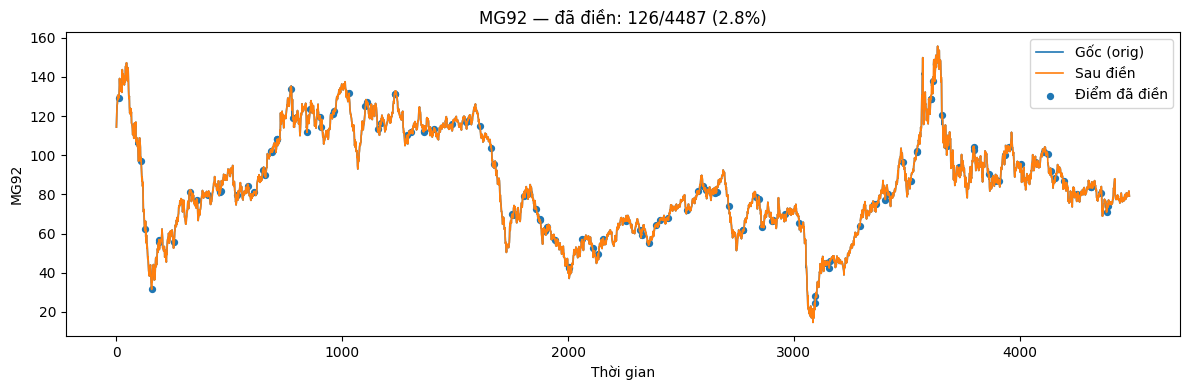

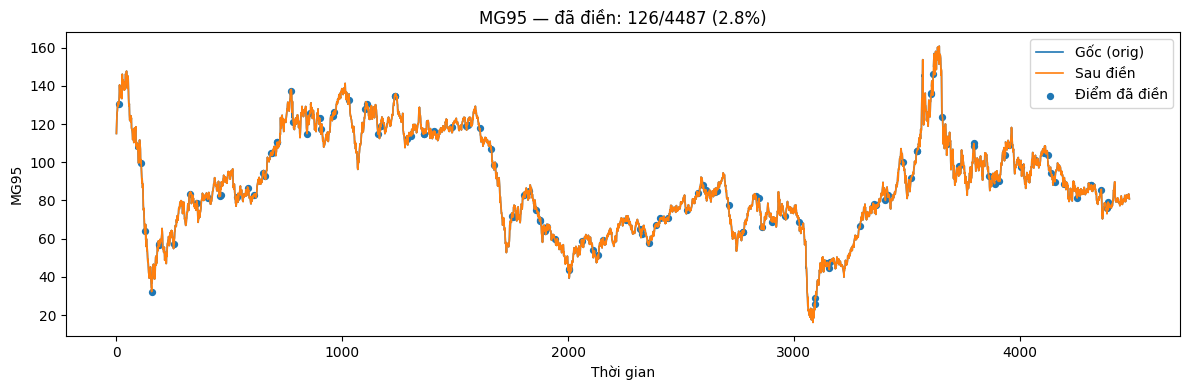

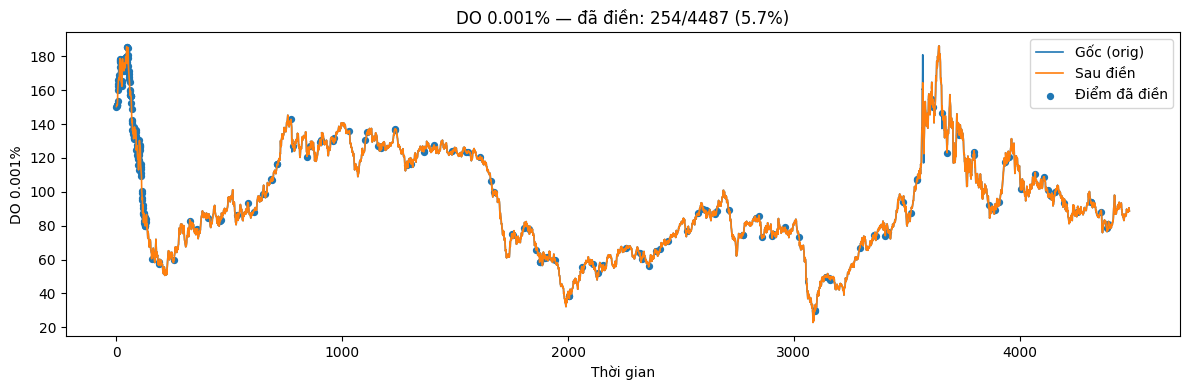

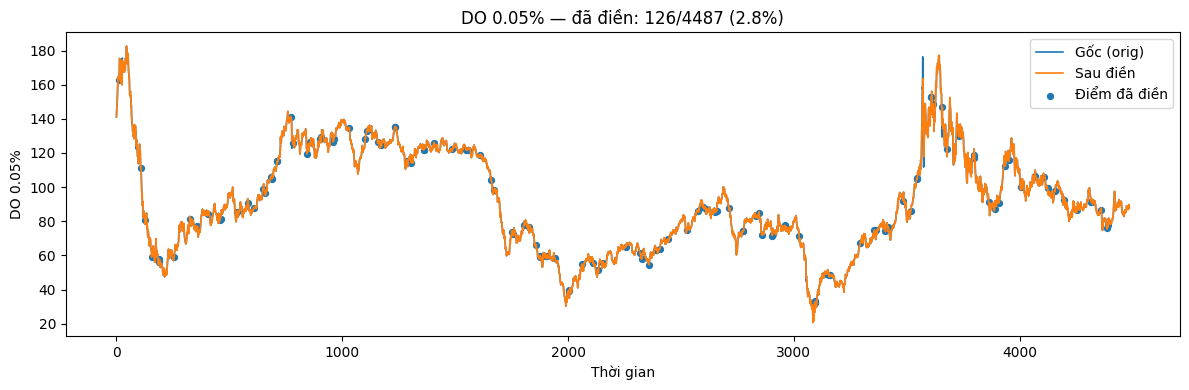

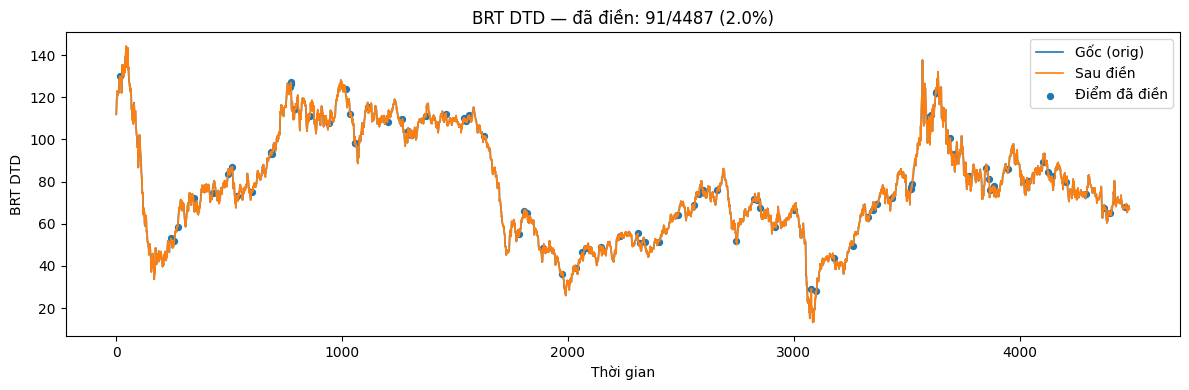

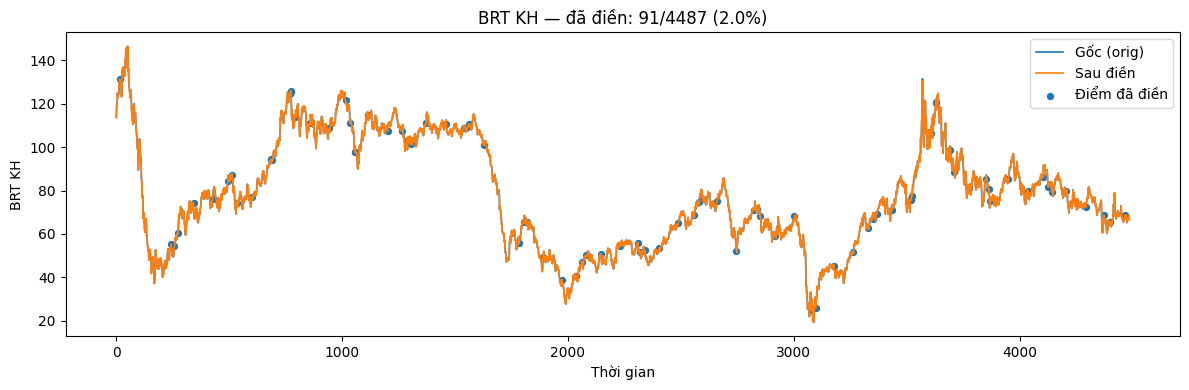

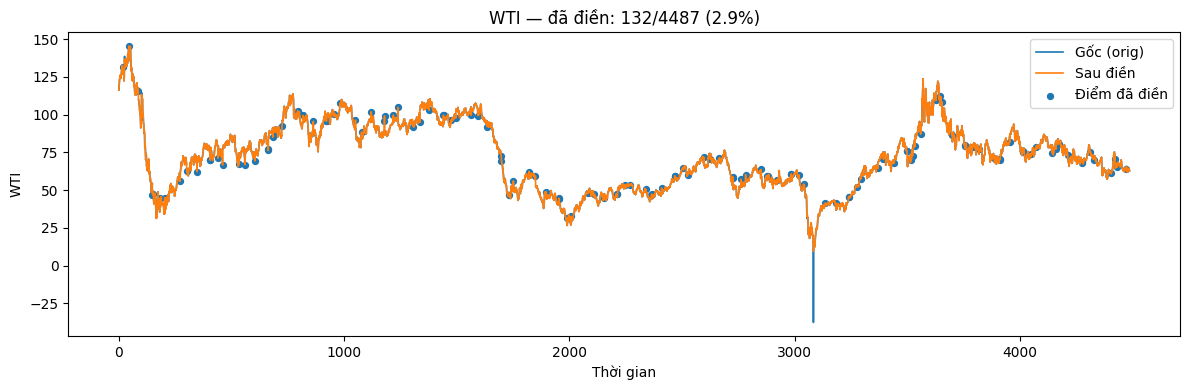

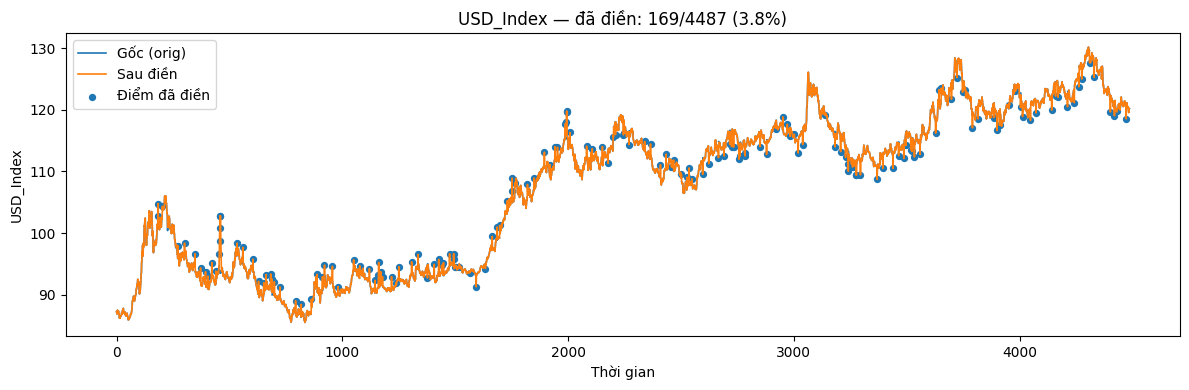

Đã lưu:
 - Ảnh: /content/drive/MyDrive/OIL/Dataset/imputation_plots
 - Dữ liệu đầy đủ: /content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_full.csv và /content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_full.xlsx
 - Dữ liệu sạch: /content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_clean.csv và /content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_clean.xlsx


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

def plot_imputation_one(df, col, save_path=None, figsize=(12,4)):
    """Vẽ so sánh: cột gốc vs sau điền + đánh dấu điểm từng NaN."""
    orig_col = f"{col}_orig"
    flag_col = f"{col}_was_nan"

    # Nếu chưa có backup/cờ thì tạo tạm để vẽ cho khỏi lỗi
    if orig_col not in df.columns:
        df[orig_col] = df[col].copy()
    if flag_col not in df.columns:
        df[flag_col] = df[col].isna().astype(int)

    if col not in df.columns:
        print(f"[BỎ QUA] Không thấy cột '{col}' trong df.")
        return

    imp_idx = df.index[df[flag_col] == 1]

    plt.figure(figsize=figsize)
    df[orig_col].plot(label="Gốc (orig)", linewidth=1.2)
    df[col].plot(label="Sau điền", linewidth=1.2)

    if len(imp_idx) > 0:
        plt.scatter(imp_idx, df.loc[imp_idx, col], s=18, label="Điểm đã điền")

    n_imp = int(df[flag_col].sum())
    n_tot = int(df[orig_col].shape[0])
    pct = 100.0 * n_imp / max(n_tot, 1)

    plt.title(f"{col} — đã điền: {n_imp}/{n_tot} ({pct:.1f}%)")
    plt.xlabel("Thời gian")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


from pathlib import Path

def plot_imputation_all(df, cont_cols, out_dir=None, figsize=(12,4)):
    for col in cont_cols:
        if col not in df.columns:
            print(f"[BỎ QUA] {col} (không có trong df)")
            continue
        save_to = None
        if out_dir:
            Path(out_dir).mkdir(parents=True, exist_ok=True)
            save_to = str(Path(out_dir) / f"imputation_{col}.png")
        plot_imputation_one(df, col, save_path=save_to, figsize=figsize)

out_img_dir = "/content/drive/MyDrive/OIL/Dataset/imputation_plots"
plot_imputation_all(df, cont_cols, out_dir=out_img_dir)

full_path_csv  = "/content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_full.csv"
full_path_xlsx = "/content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_full.xlsx"
df.to_csv(full_path_csv, index=True)
df.to_excel(full_path_xlsx, index=True)

drop_cols = [c for c in df.columns if c.endswith("_orig") or c.endswith("_was_nan") or c.endswith("_clean")]
df_clean = df.drop(columns=drop_cols, errors="ignore")
clean_path_csv  = "/content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_clean.csv"
clean_path_xlsx = "/content/drive/MyDrive/OIL/Dataset/du_lieu_noi_suy_clean.xlsx"
df_clean.to_csv(clean_path_csv, index=True)
df_clean.to_excel(clean_path_xlsx, index=True)

print("Đã lưu:")
print(" - Ảnh:", out_img_dir)
print(" - Dữ liệu đầy đủ:", full_path_csv, "và", full_path_xlsx)
print(" - Dữ liệu sạch:", clean_path_csv,  "và", clean_path_xlsx)



1) **Nội suy/điền khuyết past-only**: `ffill` + rolling median (không nhìn tương lai).
2) **Điền dựa mô hình**: RidgeCV đa biến + đặc trưng `lag` (học từ cột khác & quá khứ).
3) **Seed đầu chuỗi**: điền 3 hàng đầu để hết rỗng và tránh phẳng lì.
4) **Anti-flat**: nắn các đoạn phẳng dài chỉ ở điểm đã điền cho tự nhiên hơn.
5) **Guardrails**: clip mềm theo ngưỡng robust + giới hạn bước nhảy để tránh outlier/giật số.
6) **Backup & cờ**: lưu `*_orig` và `*_was_nan` để truy vết và dùng làm feature nếu cần.


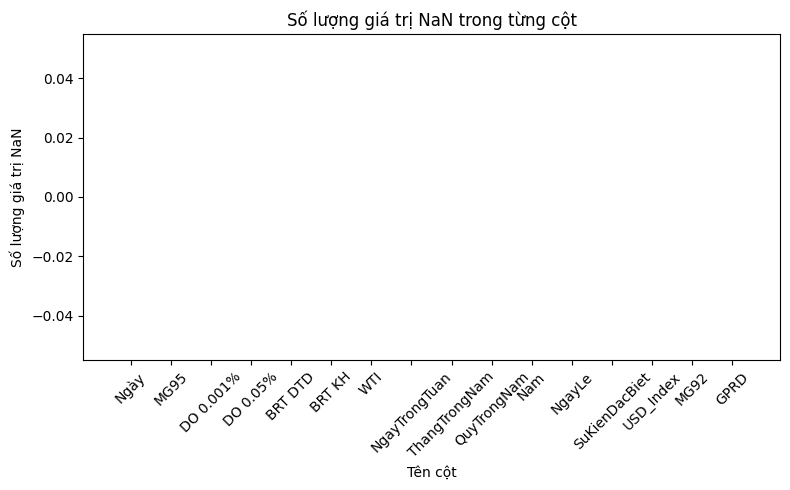

In [ ]:
nan_counts = df_clean.isna().sum()
plt.figure(figsize=(8, 5))
plt.bar(nan_counts.index, nan_counts.values)
plt.title("Số lượng giá trị NaN trong từng cột")
plt.xlabel("Tên cột")
plt.ylabel("Số lượng giá trị NaN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
path = "/content/drive/MyDrive/OIL/Dataset/root_add_4feature.xlsx"
df = pd.read_excel(path)

(4547, 21)

In [ ]:
DATE_COL = "Ngày"
TARGETS = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]

# TARGET

In [ ]:
# KIỂM TRA TARGET
print(df.shape)
print("Missing rate")
print((df[TARGETS].isna().mean()*100).round(2).astype(str)+"%")

(4547, 21)
Missing rate
MG95         90.21%
MG92         90.21%
DO 0.001%    90.21%
DO 0.05%     90.21%
dtype: object


- 4547 dòng và 21 cột.  
- ~90% số dòng không có giá trị target (NaN).  
- ~9.79% số dòng có đủ dữ liệu target.

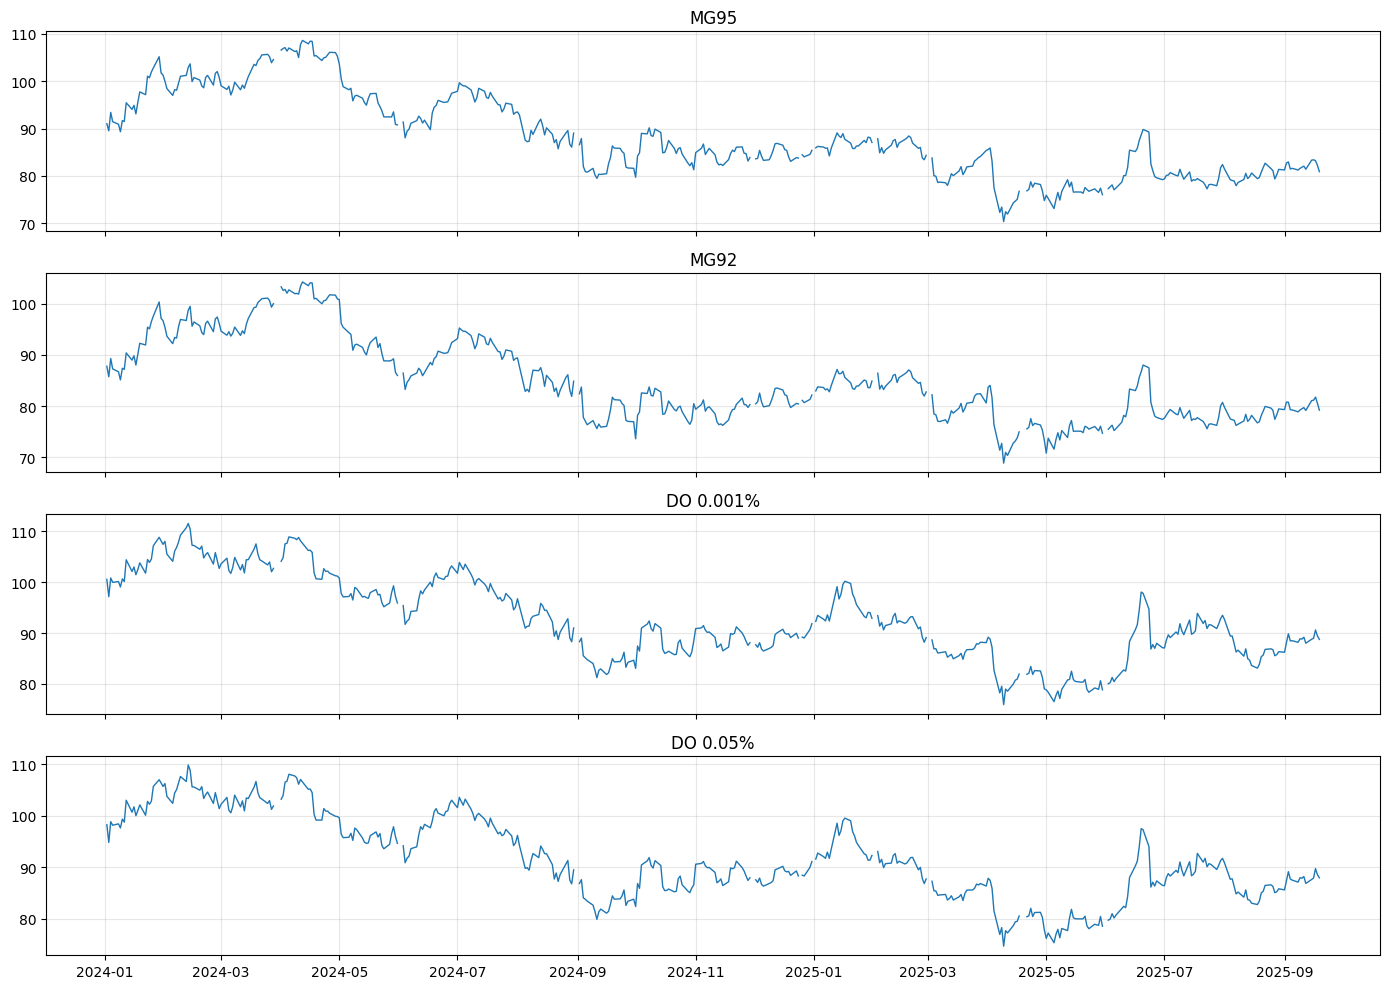

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, TARGETS):
    ax.plot(df[DATE_COL], df[col], linewidth=1)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Có các xu hướng theo giai đoạn (regime): lên mạnh đầu 2024 → giảm dần → có đoạn “giật” tăng/giảm nhanh trong 2025.  
- MG95 và MG92 bám rất sát nhau (đúng logic thị trường).  
- DO 0.001% và DO 0.05% cũng bám rất sát nhau.  

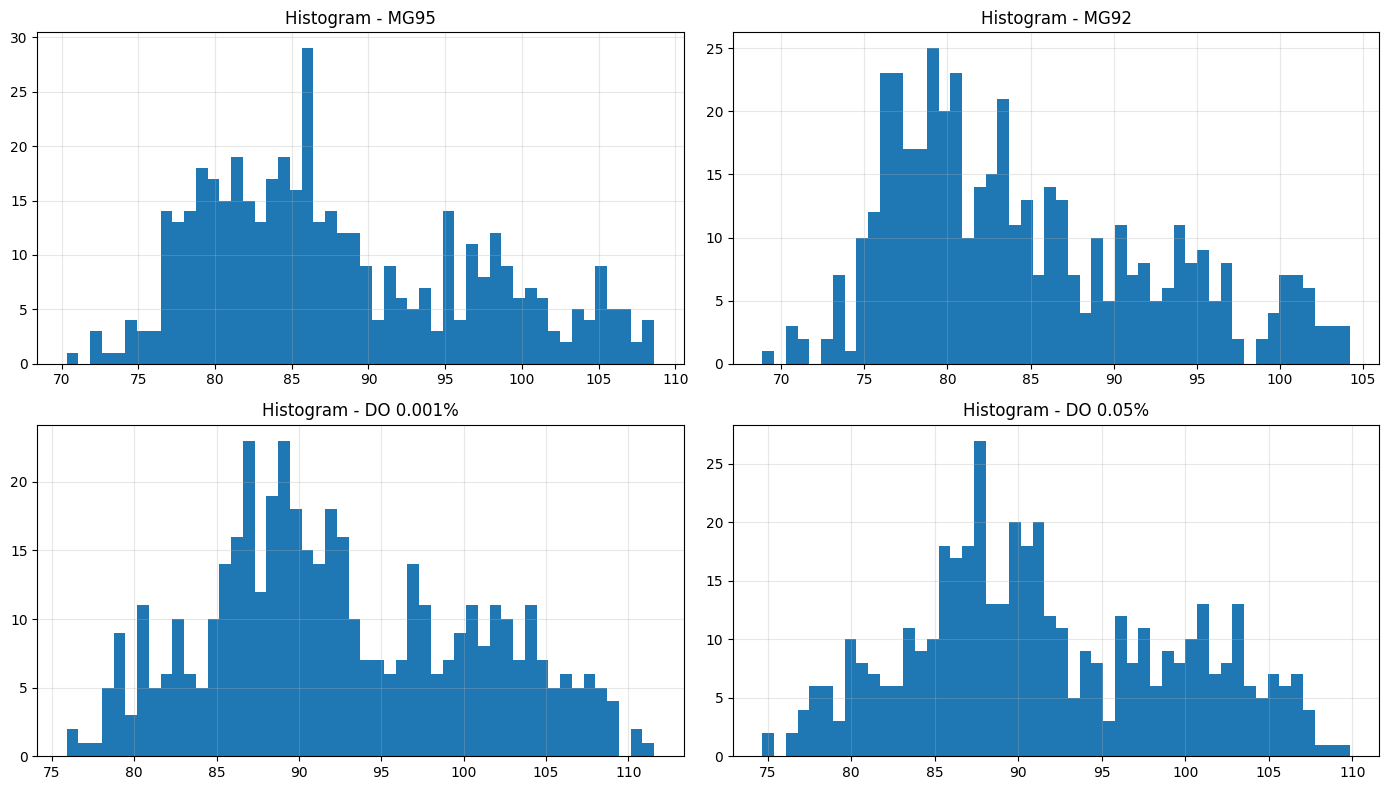

In [ ]:
# HISTOGRAM
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, TARGETS):
    x = df[col].dropna().values
    ax.hist(x, bins=50)
    ax.set_title(f"Histogram - {col}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Cột cao → khoảng giá đó xuất hiện nhiều.  
- Phân phối có vẻ không “chuẩn” hoàn toàn và có thể nhiều cụm (do mỗi giai đoạn điều hành giá tạo ra các “mặt bằng giá” khác nhau).  
-> Dải giá:  
- MG95, MG92 thường quanh ~75–105  
- DO thường quanh ~78–110 (xấp xỉ như hình)

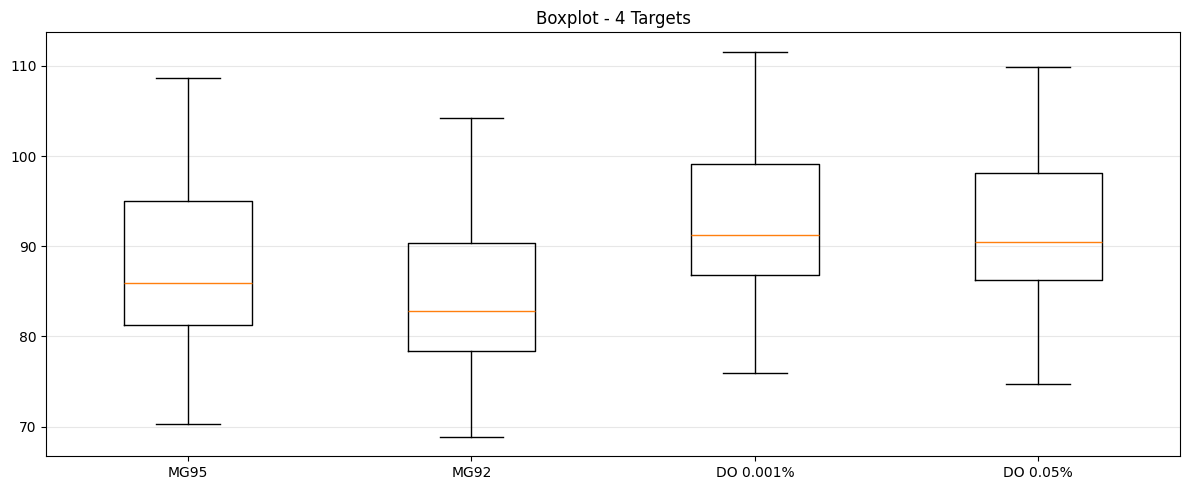

In [ ]:
# BOXPLOT SO SÁNH 4 TARGET
plt.figure(figsize=(12, 5))
plt.boxplot([df[c].dropna().values for c in TARGETS], tick_labels=TARGETS, showfliers=False)
plt.title("Boxplot - 4 Targets")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Boxplot giúp so sánh nhanh 4 target:

- Đường giữa hộp = median (giá điển hình).

- Hộp = IQR (Q1–Q3): 50% dữ liệu nằm trong hộp.

- Râu = phạm vi (bạn đang showfliers=False nên không vẽ outlier).  
Nhìn boxplot thấy:

- DO có median cao hơn nhóm xăng một chút (trong giai đoạn dữ liệu hiện có).

- Độ rộng hộp/râu cho biết biến động: hộp càng rộng → dao động càng lớn.

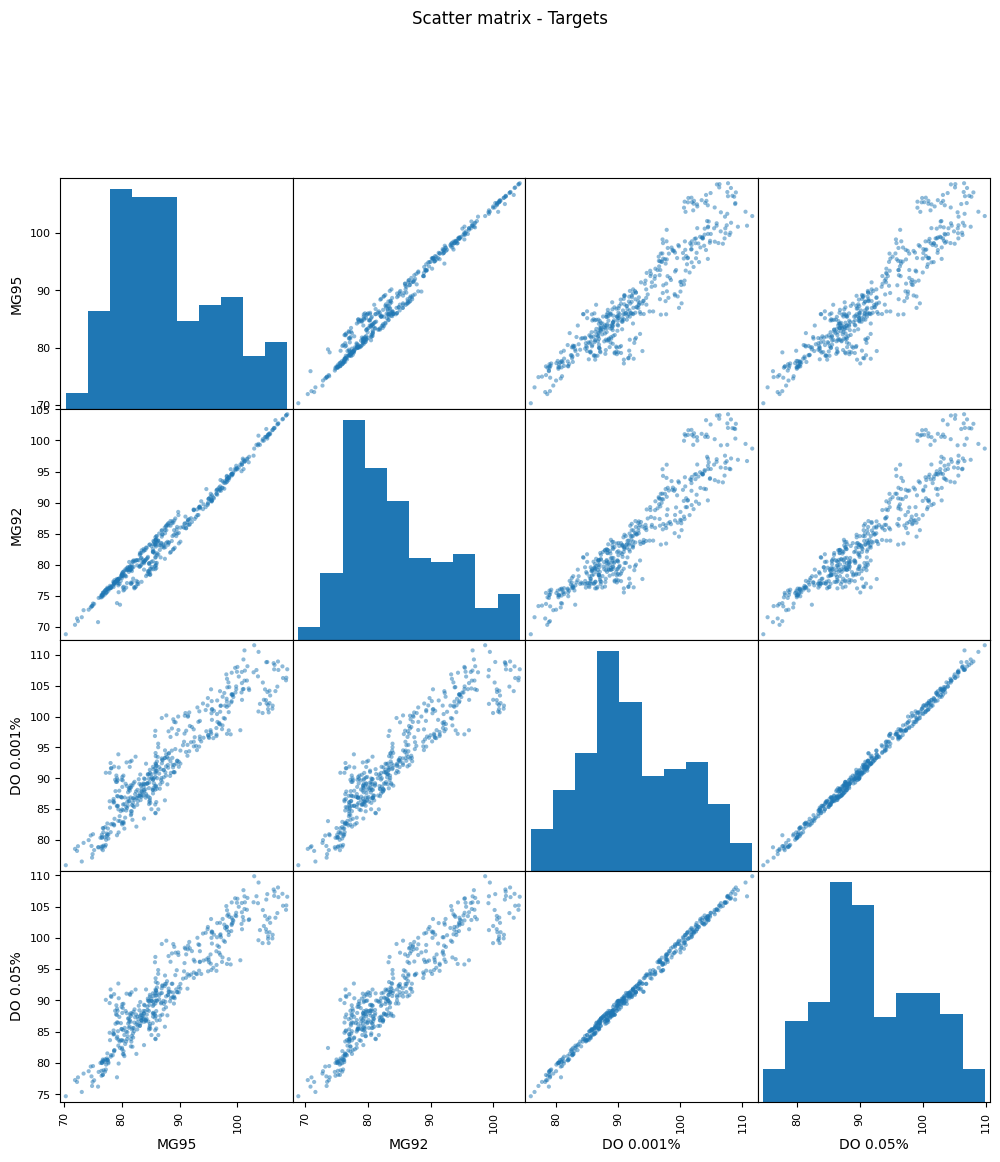

In [ ]:
#Scatter matrix
tmp = df[TARGETS].dropna()
axarr = scatter_matrix(tmp, figsize=(12, 12), diagonal="hist")
plt.suptitle("Scatter matrix - Targets", y=1.02)
plt.show()

Đường chéo (diagonal) là histogram từng biến.

Các ô ngoài đường chéo là scatter plot giữa 2 biến.
Ý nghĩa chính:

MG95 vs MG92: điểm nằm gần đường thẳng → tương quan rất cao.

DO 0.001% vs DO 0.05%: gần như một đường thẳng → tương quan cực cao.

Xăng vs DO: vẫn có quan hệ nhưng “loãng” hơn → tương quan thấp hơn.

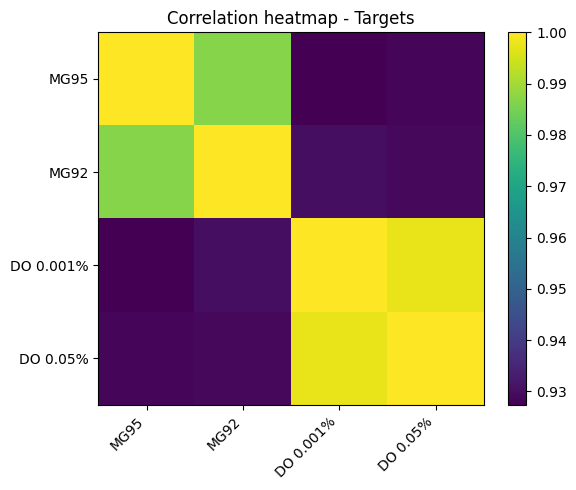

In [ ]:
# Correlation heatmap
corr = tmp.corr()
plt.figure(figsize=(6, 5))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(TARGETS)), TARGETS, rotation=45, ha="right")
plt.yticks(range(len(TARGETS)), TARGETS)
plt.title("Correlation heatmap - Targets")
plt.colorbar()
plt.tight_layout()
plt.show()

MG95–MG92: rất cao (gần 1).

DO 0.001%–DO 0.05%: gần 1 (cực cao).

Nhóm xăng ↔ dầu: thấp hơn (trong hình khoảng ~0.93), tức vẫn cùng chiều nhưng không “dính” sát như trong cùng nhóm.

#TARGET VỚI TỪNG FEATURE

In [ ]:
#xác định FEATURES
FEATURES = [c for c in df.columns if c not in TARGETS and c != DATE_COL]

In [ ]:
#ép numeric cho features/targets
df_num = df.copy()
for c in FEATURES + TARGETS:
    df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

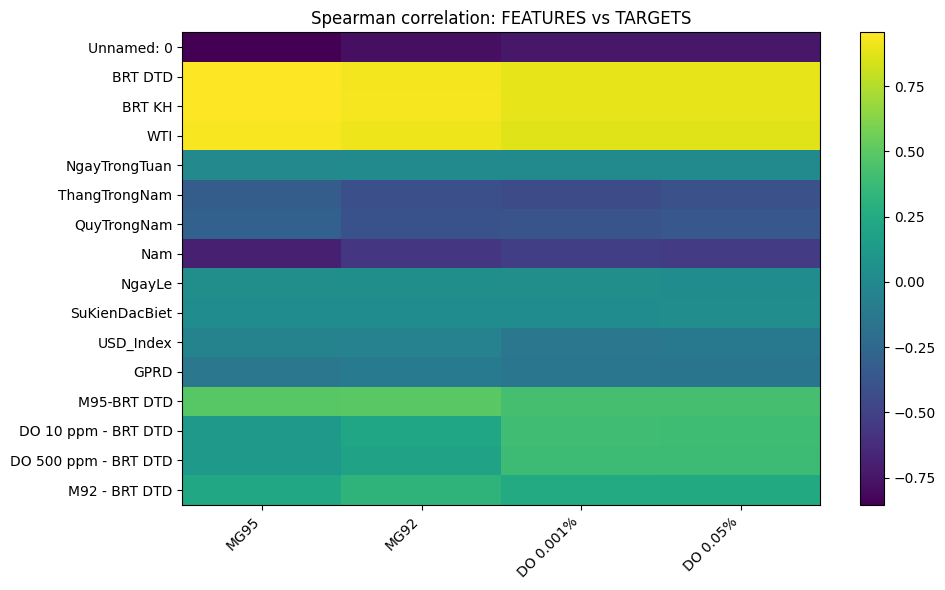

In [ ]:
#Corr heatmap: targets x features
corr_tf = pd.DataFrame(index=FEATURES, columns=TARGETS, dtype=float)
for t in TARGETS:
    for f in FEATURES:
        sub = df_num[[f, t]].dropna()
        corr_tf.loc[f, t] = sub[f].corr(sub[t], method="spearman") if len(sub) >= 5 else np.nan

plt.figure(figsize=(10, max(6, len(FEATURES)*0.35)))
plt.imshow(corr_tf.values, aspect="auto")
plt.yticks(range(len(FEATURES)), FEATURES)
plt.xticks(range(len(TARGETS)), TARGETS, rotation=45, ha="right")
plt.title("Spearman correlation: FEATURES vs TARGETS")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
corr_tf = pd.DataFrame(index=FEATURES, columns=TARGETS, dtype=float)
n_tf    = pd.DataFrame(index=FEATURES, columns=TARGETS, dtype=int)

In [ ]:
for f in FEATURES:
    for t in TARGETS:
        sub = df_num[[f, t]].dropna()
        n_tf.loc[f, t] = len(sub)
        corr_tf.loc[f, t] = sub[f].corr(sub[t], method="spearman") if len(sub) >= 5 else np.nan

In [ ]:
corr_tf_rounded = corr_tf.round(4)

In [ ]:
display(corr_tf_rounded)

,MG95,MG92,DO 0.001%,DO 0.05%
Unnamed: 0,-0.8545,-0.7801,-0.7404,-0.7388
BRT DTD,0.9515,0.9257,0.8860,0.8874
BRT KH,0.9564,0.9304,0.8873,0.8887
WTI,0.9362,0.9127,0.8665,0.8694
NgayTrongTuan,-0.0007,0.0037,0.0076,0.0110
ThangTrongNam,-0.3202,-0.4155,-0.4308,-0.4072
QuyTrongNam,-0.2951,-0.3952,-0.3832,-0.3596
Nam,-0.6960,-0.5689,-0.5194,-0.5315
NgayLe,0.0408,0.0444,0.0403,0.0235
SuKienDacBiet,0.0290,0.0290,0.0276,0.0349


In [ ]:
display(n_tf)

,MG95,MG92,DO 0.001%,DO 0.05%
Unnamed: 0,445.0,445.0,445.0,445.0
BRT DTD,445.0,445.0,445.0,445.0
BRT KH,445.0,445.0,445.0,445.0
WTI,445.0,445.0,445.0,445.0
NgayTrongTuan,445.0,445.0,445.0,445.0
ThangTrongNam,445.0,445.0,445.0,445.0
QuyTrongNam,445.0,445.0,445.0,445.0
Nam,445.0,445.0,445.0,445.0
NgayLe,445.0,445.0,445.0,445.0
SuKienDacBiet,445.0,445.0,445.0,445.0
